In [10]:
import pandas as pd
import psycopg2
from psycopg2 import sql
from gold_common_functions import connect_to_postgres
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
SOURCE_QUERY = """
SELECT
	p.*,
	c.category_final
FROM gold.products AS p
JOIN gold.categories AS c
	ON p.category_key = c.category_key
WHERE 
	p.snapshot_date IN (SELECT DISTINCT snapshot_date FROM gold.products LIMIT 10)
"""

In [12]:
conn = connect_to_postgres()
if conn:
    df = pd.read_sql(SOURCE_QUERY, conn)
    conn.close()

✅ Conectado a PostgreSQL


/tmp/ipykernel_1949/536786609.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SOURCE_QUERY, conn)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256398 entries, 0 to 256397
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   snapshot_date    256398 non-null  object        
 1   supermarket      256398 non-null  object        
 2   product_id       144450 non-null  object        
 3   product_name     256398 non-null  object        
 4   brand            135805 non-null  object        
 5   price            256398 non-null  float64       
 6   unit_of_measure  160720 non-null  object        
 7   is_on_promotion  48772 non-null   object        
 8   promotion_price  15217 non-null   float64       
 9   category_slug    256398 non-null  object        
 10  ingestion_time   256398 non-null  datetime64[ns]
 11  created_at       256398 non-null  datetime64[ns]
 12  final_price      256398 non-null  float64       
 13  tom_brand        256398 non-null  object        
 14  category_key     256

# Categories

In [14]:
# 1. Agregación de todas las métricas necesarias (count, max, min, mean, median)
# Filtramos (no 'Otros')
df_metrics = df[df['category_final'] != 'Otros'].groupby(['category_final', 'supermarket'])['final_price'].agg(
    count='count',
    max_price='max',
    min_price='min',
    mean_price='mean',
    median_price='median'
).reset_index()

category_final_list = df_metrics['category_final'].unique()

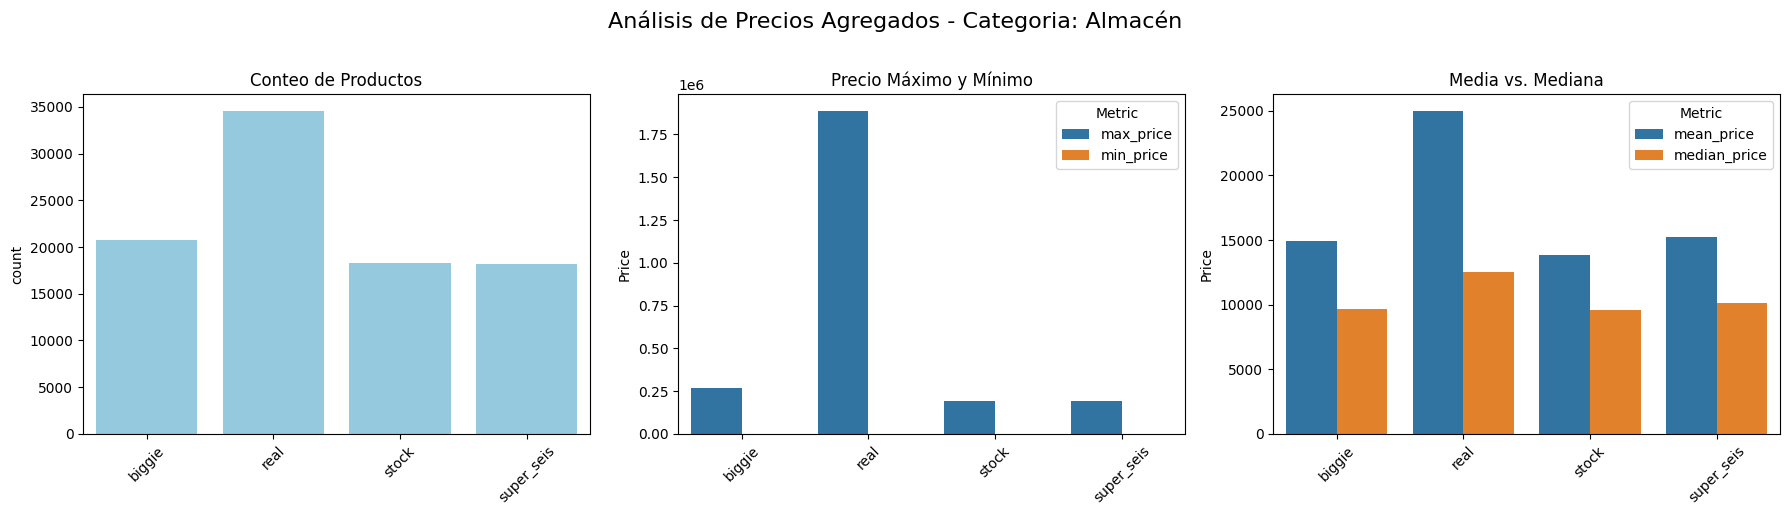

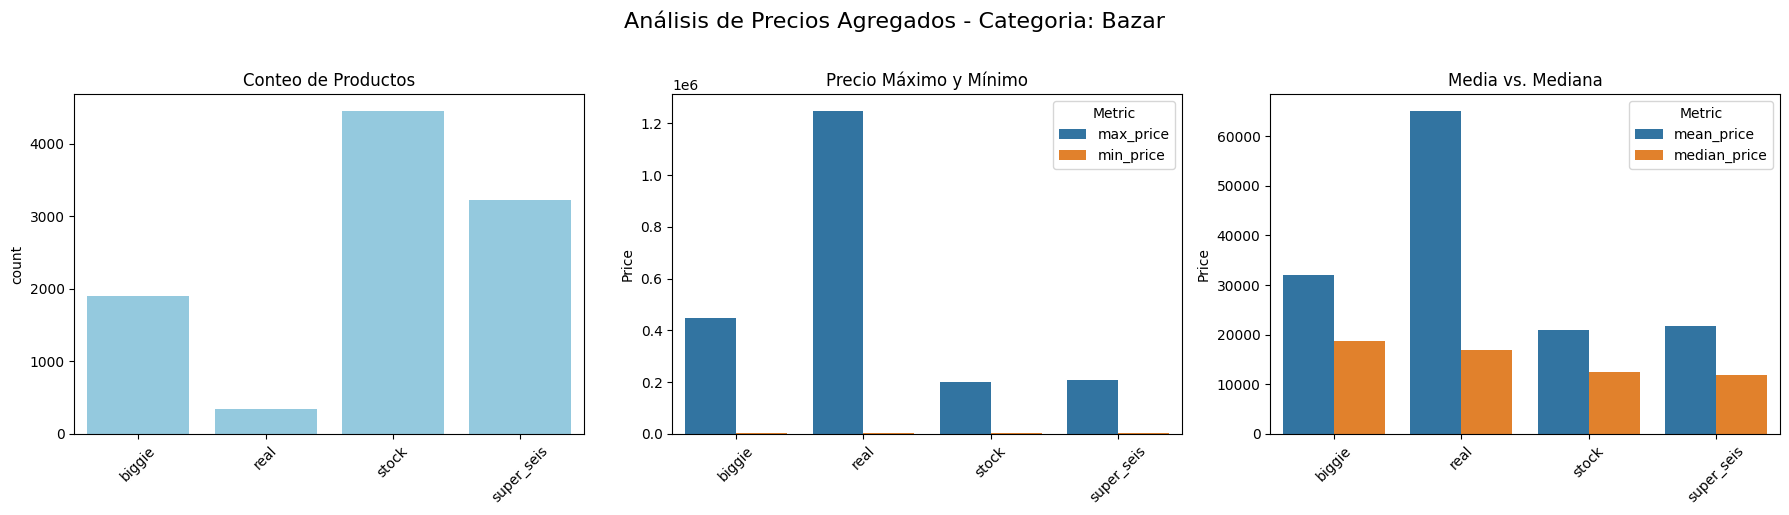

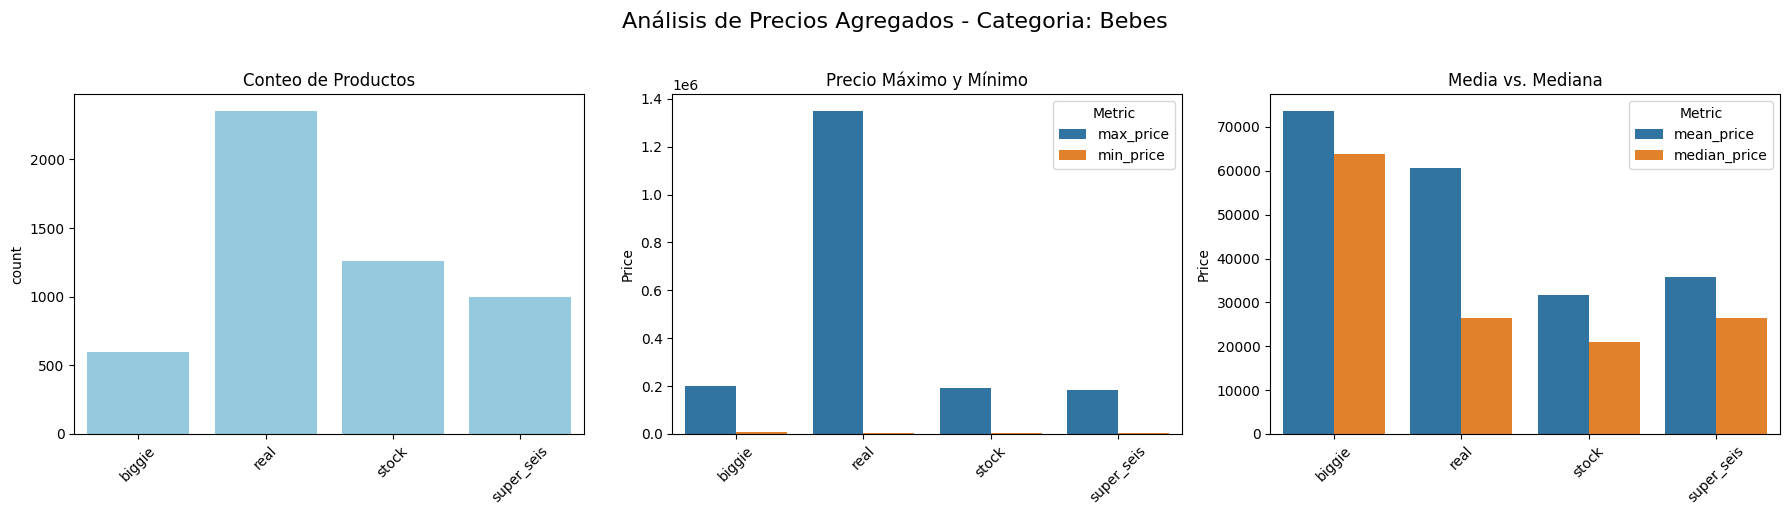

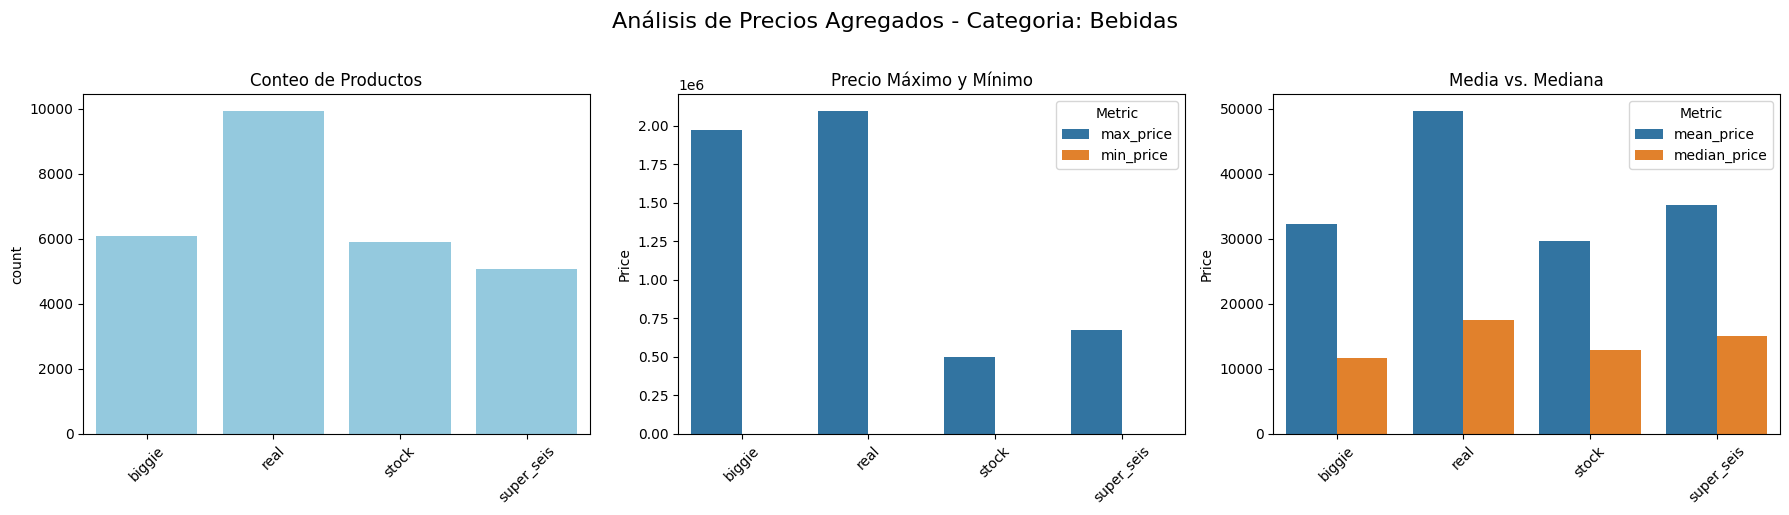

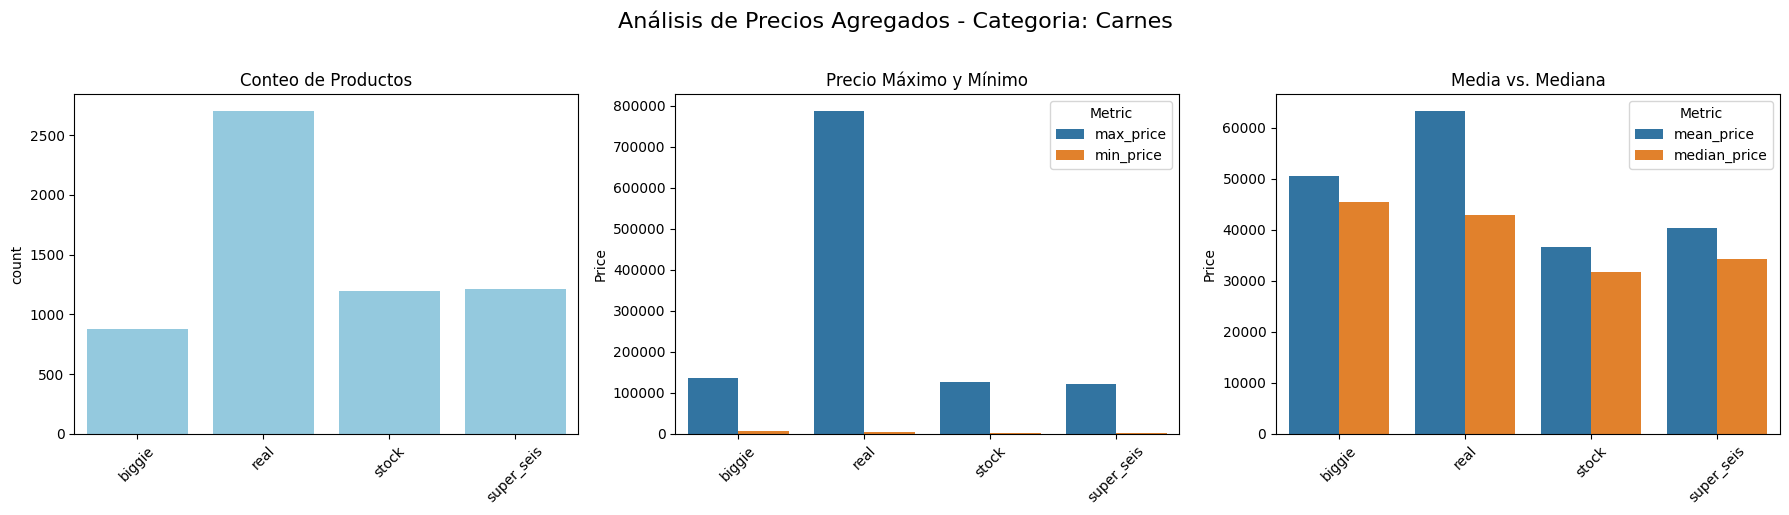

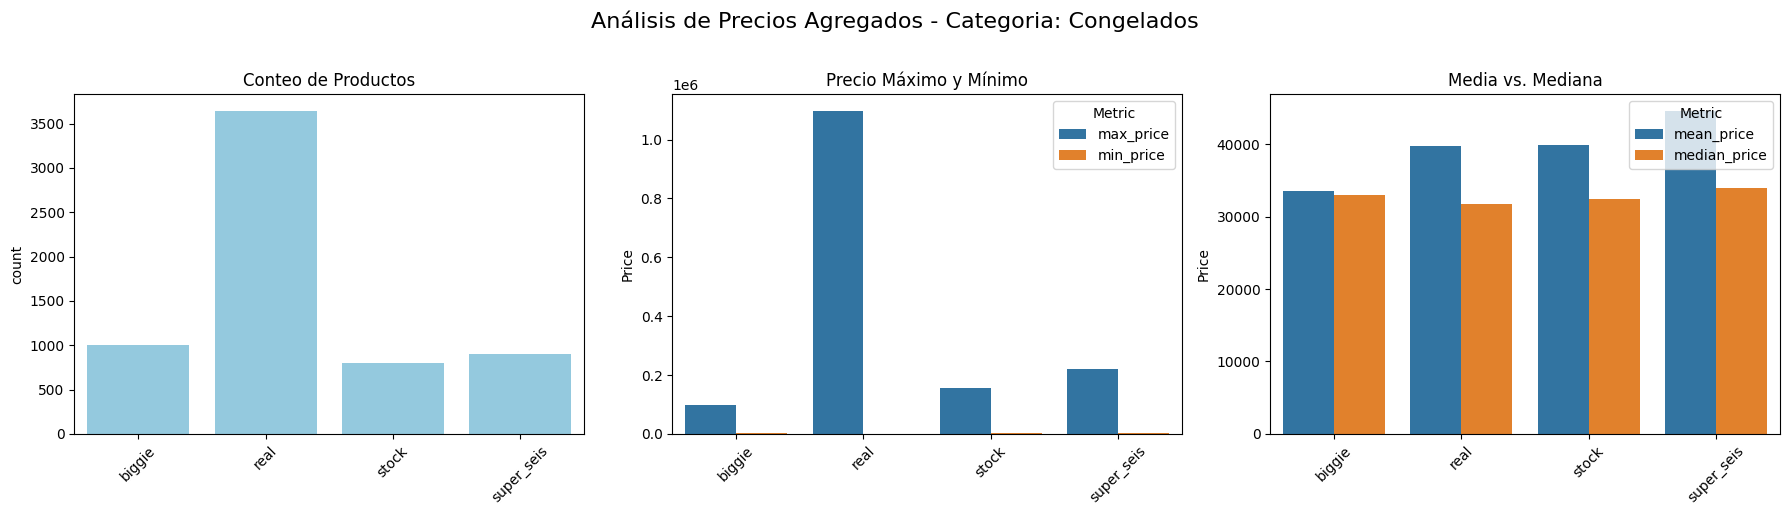

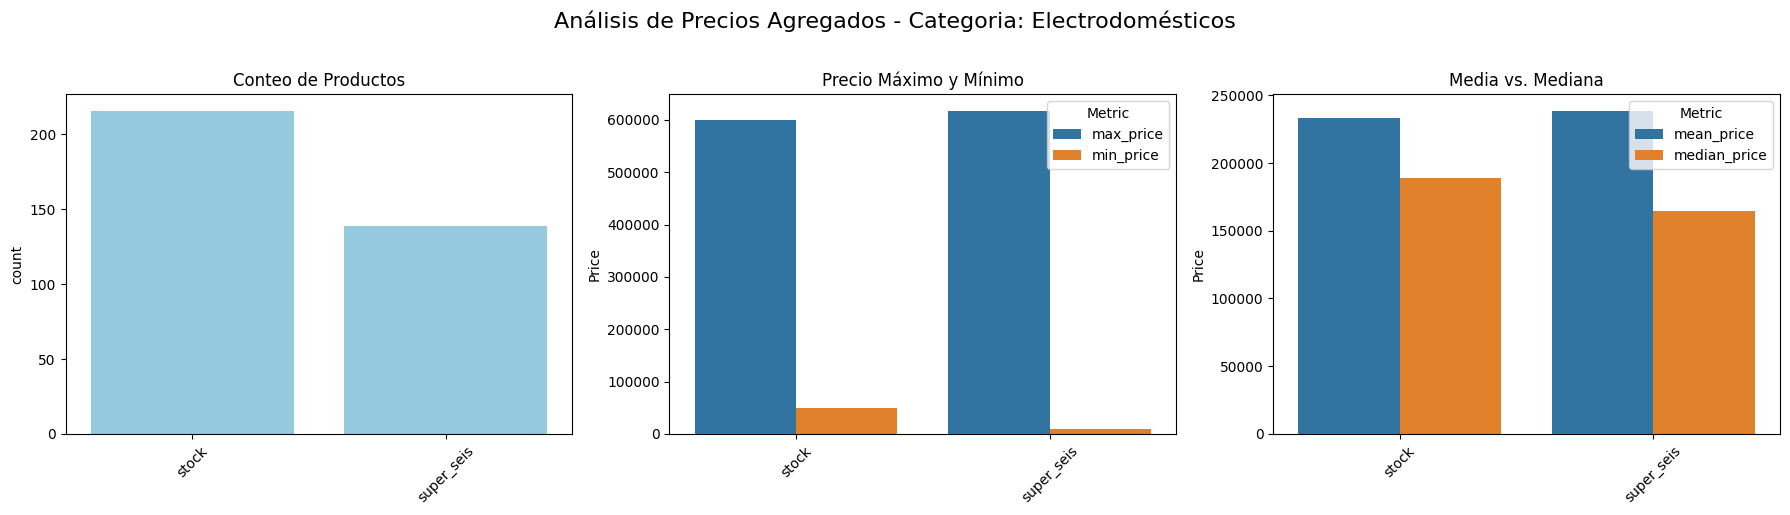

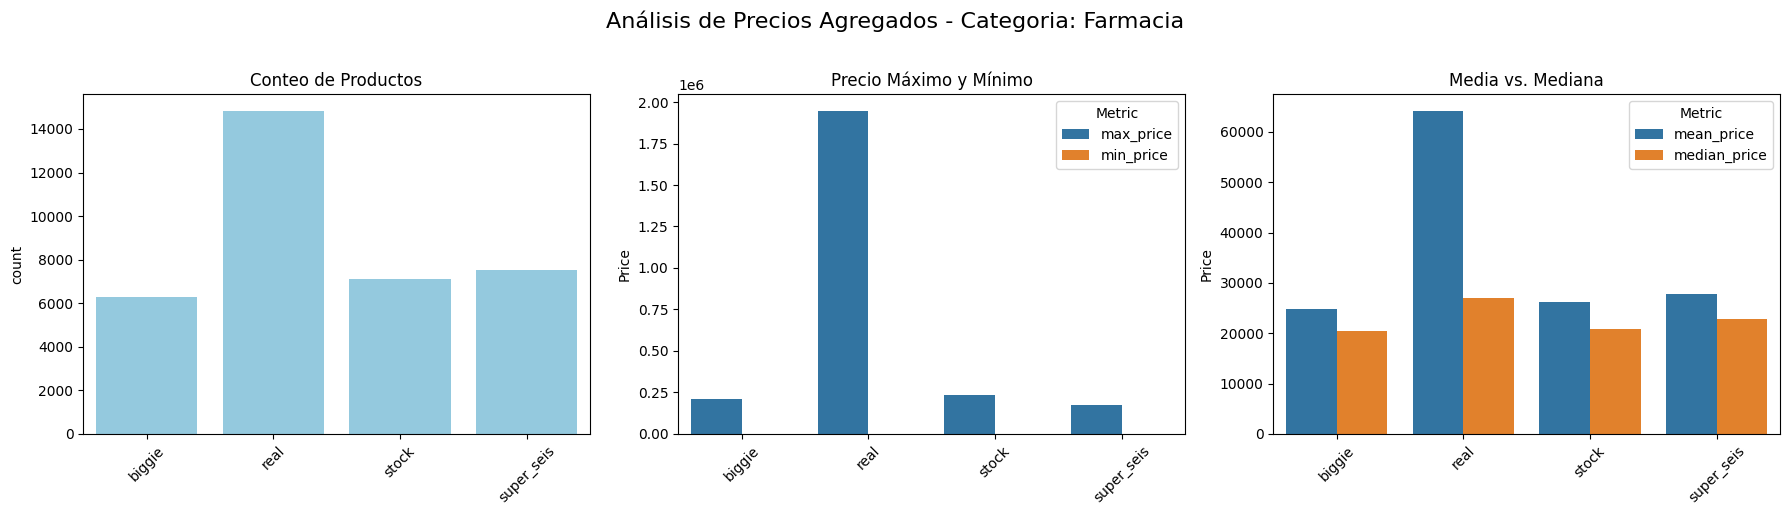

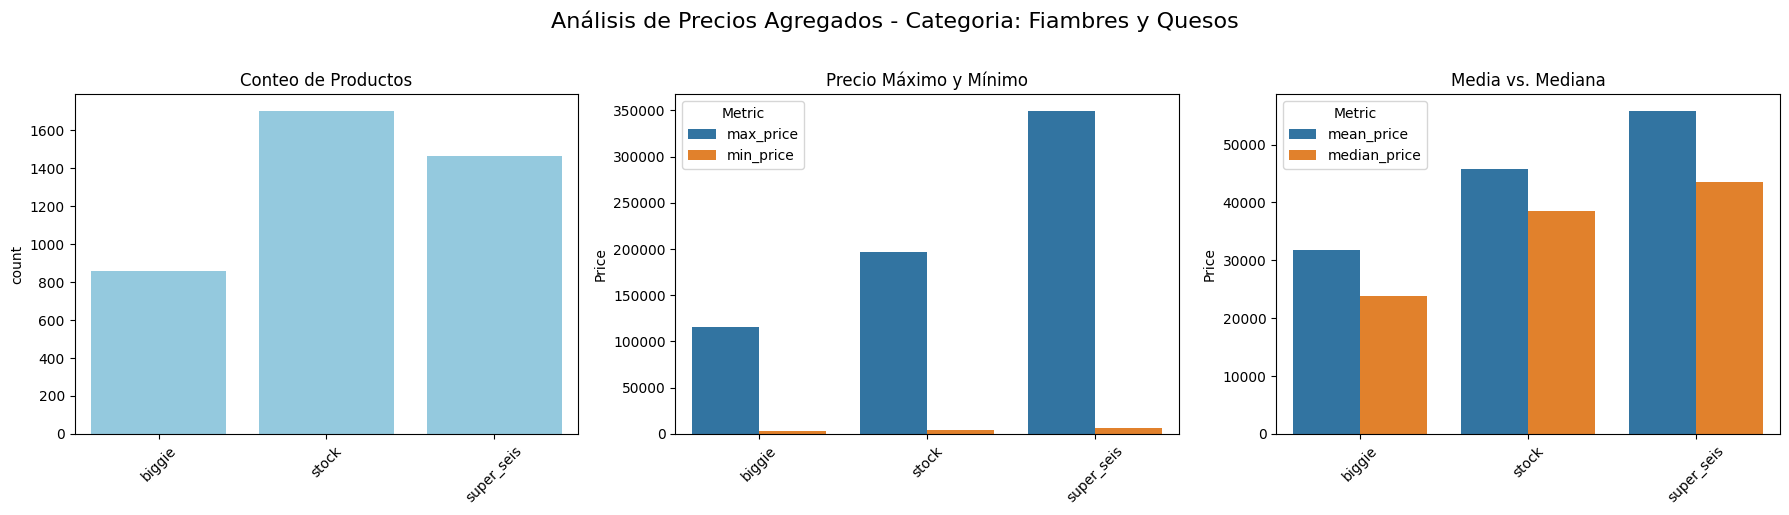

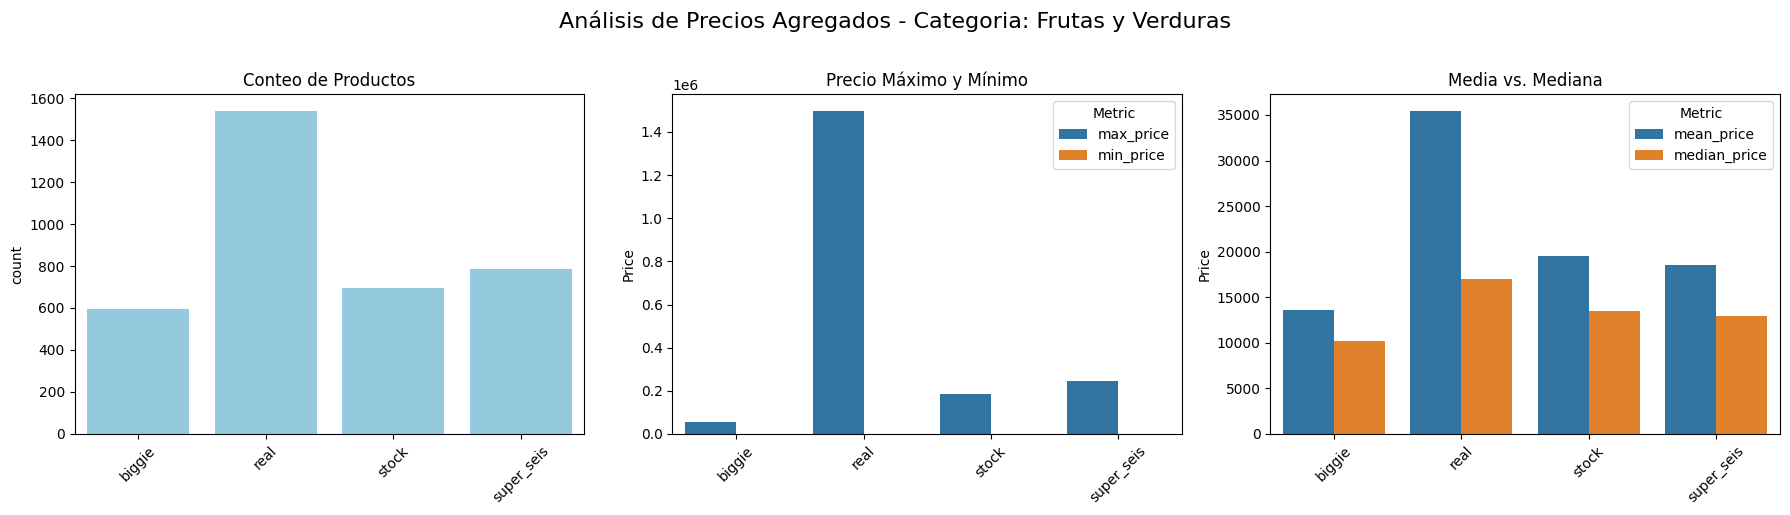

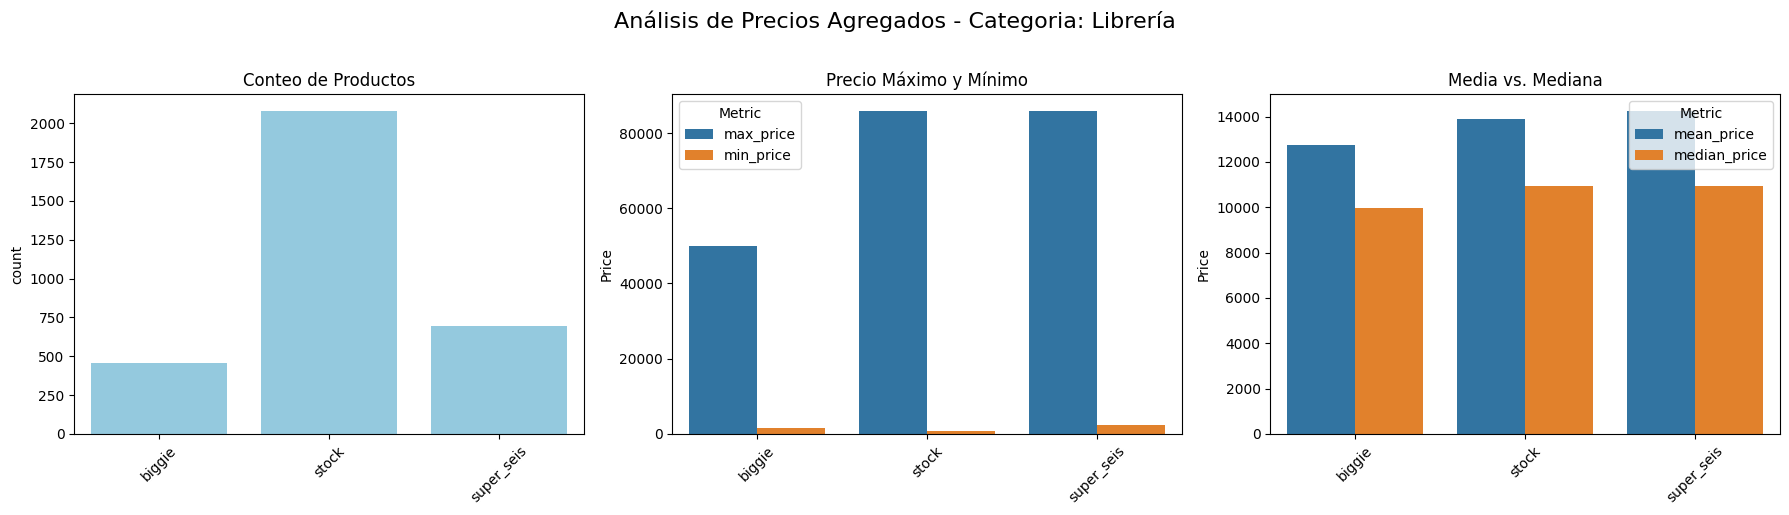

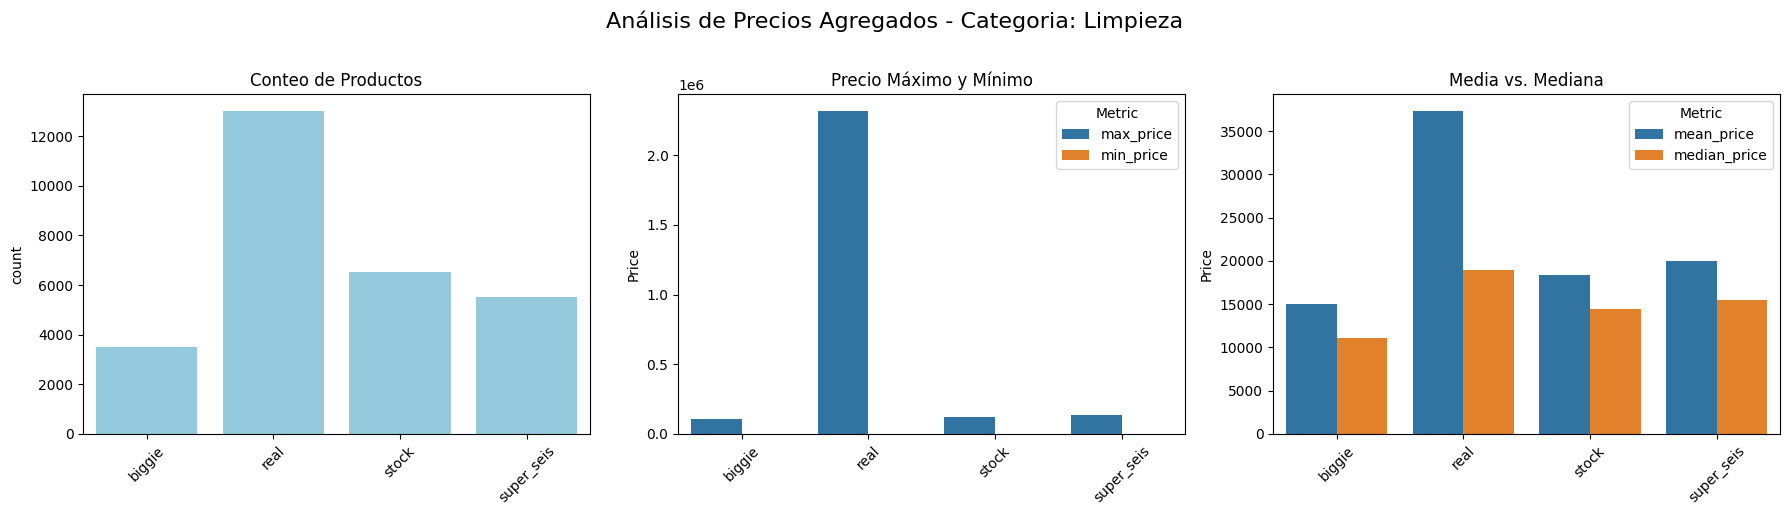

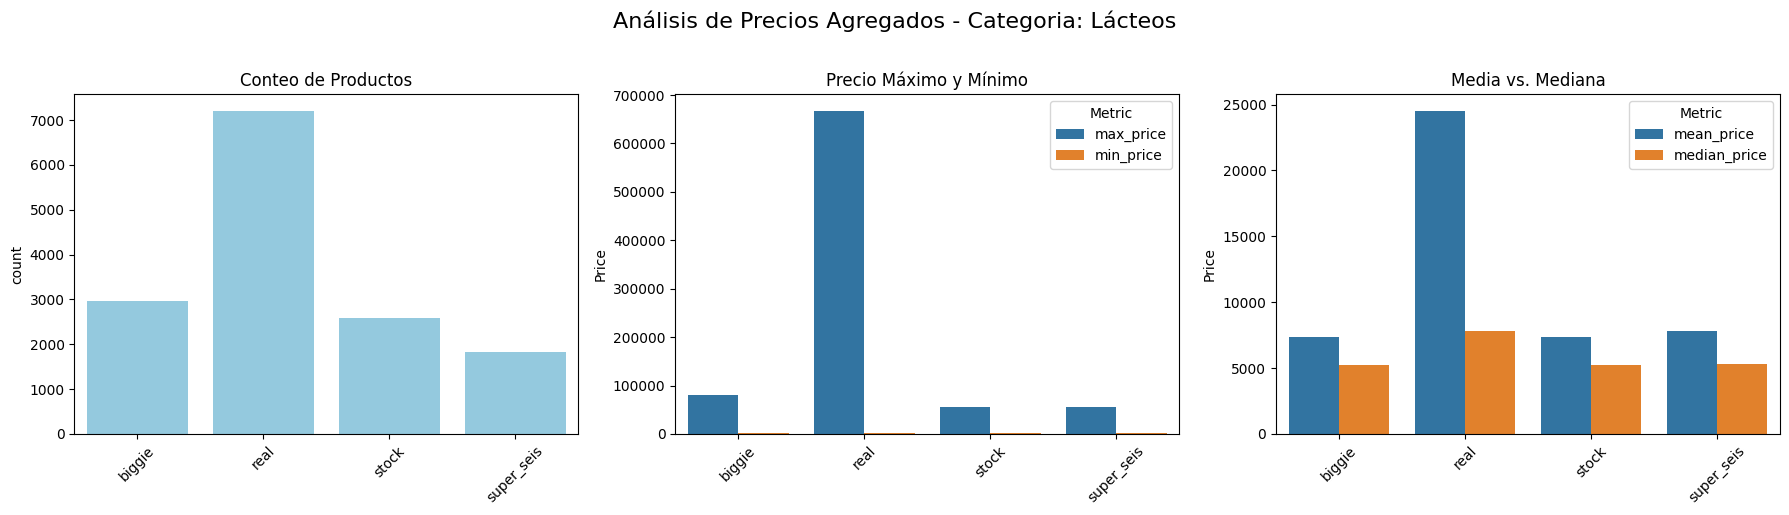

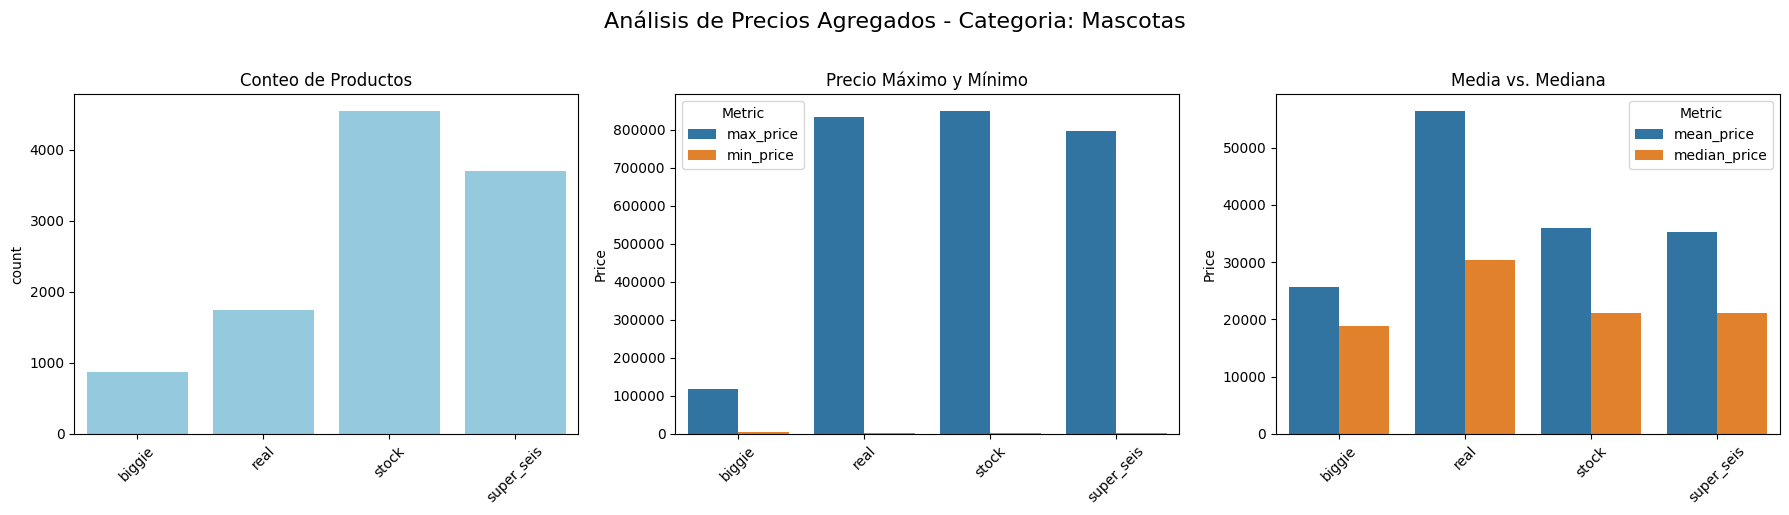

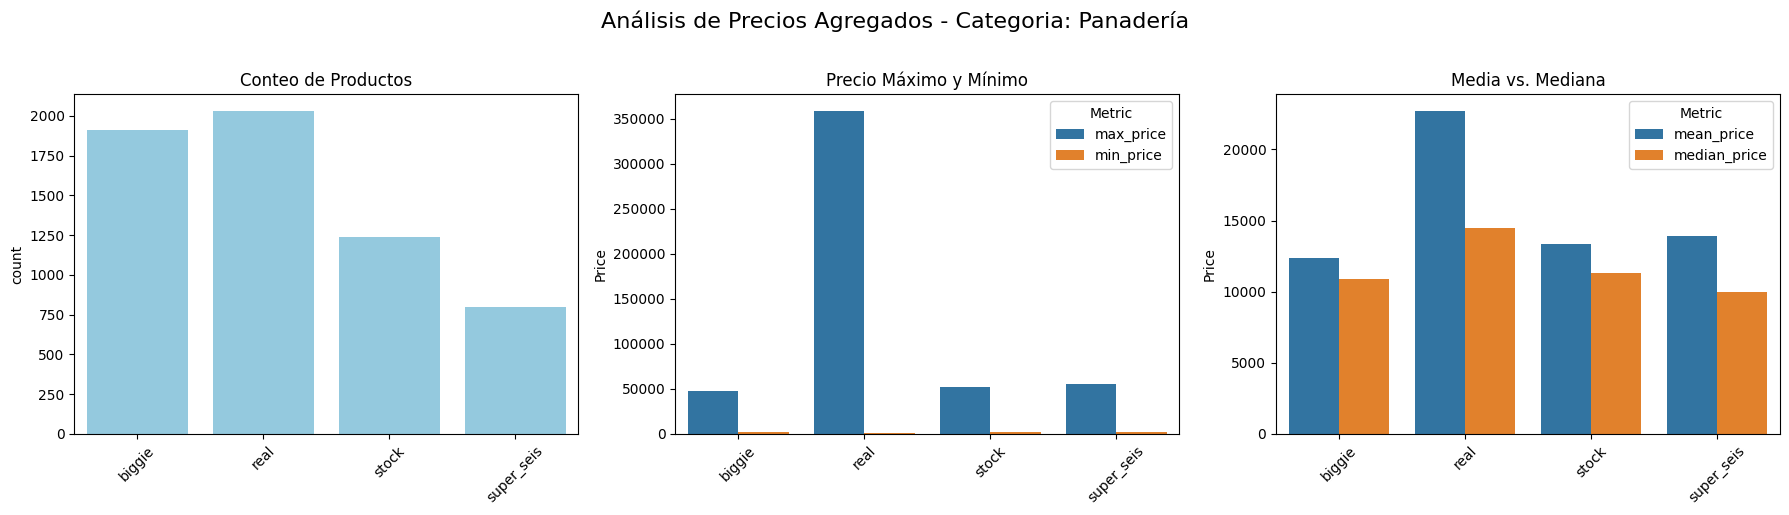

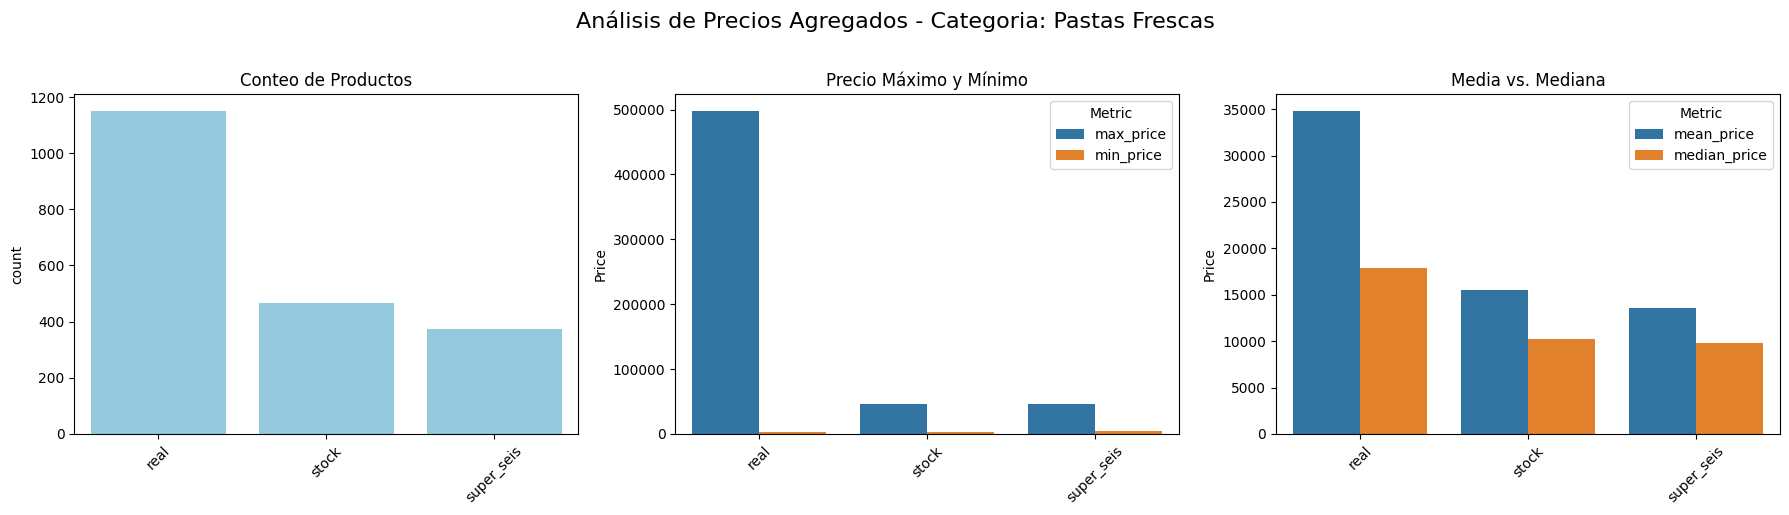

In [15]:
# Iteramos sobre cada categoria
for category in category_final_list:
    category_data = df_metrics[df_metrics['category_final'] == category]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.suptitle(f'Análisis de Precios Agregados - Categoria: {category}', fontsize=16, y=1.02)

    # --- PLOT 1: Count (Cantidad de Productos) ---
    sns.barplot(
        data=category_data, 
        x='supermarket', 
        y='count', 
        ax=axes[0],
        color='skyblue'
    )
    axes[0].set_title('Conteo de Productos')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=45)
    
    # --- PLOT 2: Max y Min Price (Range) ---
    range_data = category_data[['supermarket', 'max_price', 'min_price']].melt(
        id_vars='supermarket', 
        var_name='Metric', 
        value_name='Price'
    )
    sns.barplot(
        data=range_data, 
        x='supermarket', 
        y='Price', 
        hue='Metric', 
        ax=axes[1]
    )
    axes[1].set_title('Precio Máximo y Mínimo')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)

    # --- PLOT 3: Mean y Median Price ---
    central_data = category_data[['supermarket', 'mean_price', 'median_price']].melt(
        id_vars='supermarket', 
        var_name='Metric', 
        value_name='Price'
    )
    sns.barplot(
        data=central_data, 
        x='supermarket', 
        y='Price', 
        hue='Metric', 
        ax=axes[2]
    )
    axes[2].set_title('Media vs. Mediana')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# TOM

### Preparacion

In [16]:
df['search_term'] = (
    df['product_name']
    .str.lower()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

tom_brands = {
    'Pechugón': r'pechugon',
    'Cavallaro': r'cavallaro',
    'Tres Leones': r'tres\s*leones', # \s* maneja 0 o más espacios
    'Lactolanda': r'lactolanda',
    'Kurupí': r'kurupi',
    'Ochsi': r'ochsi',
    'Hellmann\'s': r'hellmann',
    'Trébol': r'trebol',
    'Coca-Cola': r'coca.*cola', # .* permite "Coca Cola" o "Coca-Cola"
    'Sedal': r'sedal',
    'Pedigree': r'pedigree',
    'Mar': r'\bmar\b', # \b asegura palabra exacta (evita "maravilla")
    'Nikito': r'nikito',
    'OMO': r'\bomo\b',
    'Guaraní': r'guarani',
    'Mapex': r'mapex',
    'Caricias': r'caricia',
    'Ades': r'\bades\b',
    'Anita': r'\banita\b',
    'Brahma': r'brahma',
    'Red Bull': r'red\s*bull',
    'Nescafé': r'nescafe',
    'Huggies': r'huggies',
    'Incabril': r'incabril',
    'Colgate': r'colgate',
    'Rexona': r'rexona',
    'Nestlé': r'nestle'
}

In [17]:
df['tom_brand'] = 'Otros' # Valor por defecto

for brand_label, pattern in tom_brands.items():
    mask = df['search_term'].str.contains(pattern, regex=True, na=False)
    df.loc[mask, 'tom_brand'] = brand_label

df.drop(columns=['search_term'], inplace=True)

print(df[df['tom_brand'] != 'Otros']['tom_brand'].value_counts())

tom_brand
Lactolanda     2692
Trébol         2396
Colgate        2102
Guaraní        1879
Cavallaro      1532
Rexona         1201
Nestlé         1160
Ochsi           982
Pechugón        951
Sedal           889
Huggies         857
Pedigree        774
Mapex           749
Coca-Cola       655
Kurupí          654
Anita           652
Hellmann's      565
Mar             543
Nescafé         521
Tres Leones     492
OMO             418
Ades            365
Caricias        285
Incabril        225
Brahma          146
Nikito           56
Red Bull         30
Name: count, dtype: int64


In [18]:
df['product_name'][df["tom_brand"] == "Huggies"].sample(10)

33301        Huggies Supreme Natural Care RN De 34 unidades
251329        TOALLITA HUMEDA CUIDADO 4 EN 1 HUGGIES 48UNID
160497        PAÑALES LITTLE SWIMMERS M HUGGIES 11 UNIDADES
105698    Pañales Huggies Protect Plus XXG Ahorro Pack 5...
160534     TOALLA HÚMEDA CUIDADO 4 EN 1 HUGGIES 48 UNIDADES
217568      PAÑALES DESECHABLES XXG 30 UNID HUGGIES COMFORT
209129     PAÑALES DESECHABLES XXXG 48 UNID HUGGIES COMFORT
42038     Pañal Huggies Protec Plus XG Ahorro Pack x 52 ...
73023         Pañales Huggies Ahorra Pack XXXG 48 Unidades 
136480    Pañales Huggies Supreme Natural Care RN 30 uni...
Name: product_name, dtype: object

In [19]:
df_chart = df[['supermarket', 'final_price']][df["tom_brand"] == "Lactolanda"].copy()
df_chart = df_chart.groupby('supermarket')['final_price'].agg(["count","sum"]).reset_index()
df_chart.head()

,supermarket,count,sum
0,biggie,616,4370000.0
1,real,872,31699350.0
2,stock,599,10012550.0
3,super_seis,605,10859550.0


<Axes: title={'center': 'Lactolanda: Cantidad vs. Precio Total'}, xlabel='supermarket'>

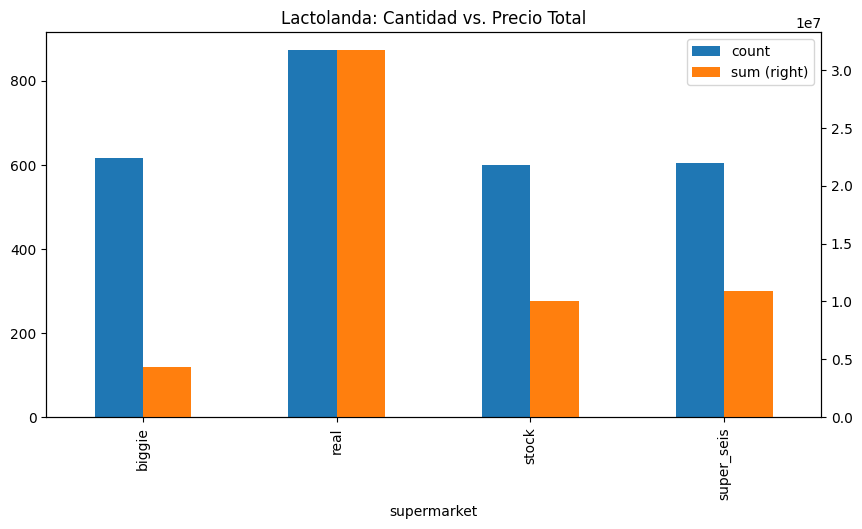

In [20]:
datos = df[df["tom_brand"] == "Lactolanda"].groupby('supermarket')['final_price'].agg(["count", "sum"])
datos.plot(kind='bar', secondary_y='sum', figsize=(10, 5), title="Lactolanda: Cantidad vs. Precio Total")

### Visualizacion

In [21]:
# 1. Agregación de todas las métricas necesarias (count, max, min, mean, median)
# Filtramos (no 'Otros')
df_metrics = df[df['tom_brand'] != 'Otros'].groupby(['tom_brand', 'supermarket'])['final_price'].agg(
    count='count',
    max_price='max',
    min_price='min',
    mean_price='mean',
    median_price='median'
).reset_index()

tom_brands_list = df_metrics['tom_brand'].unique()

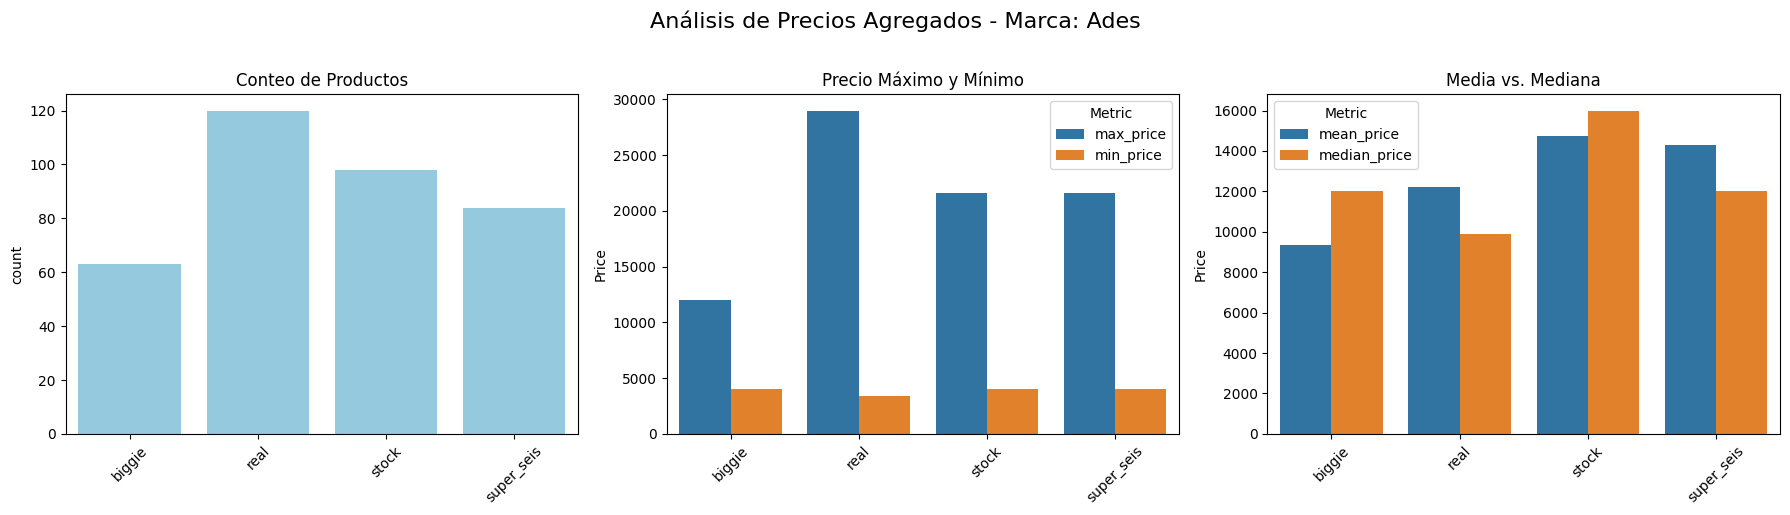

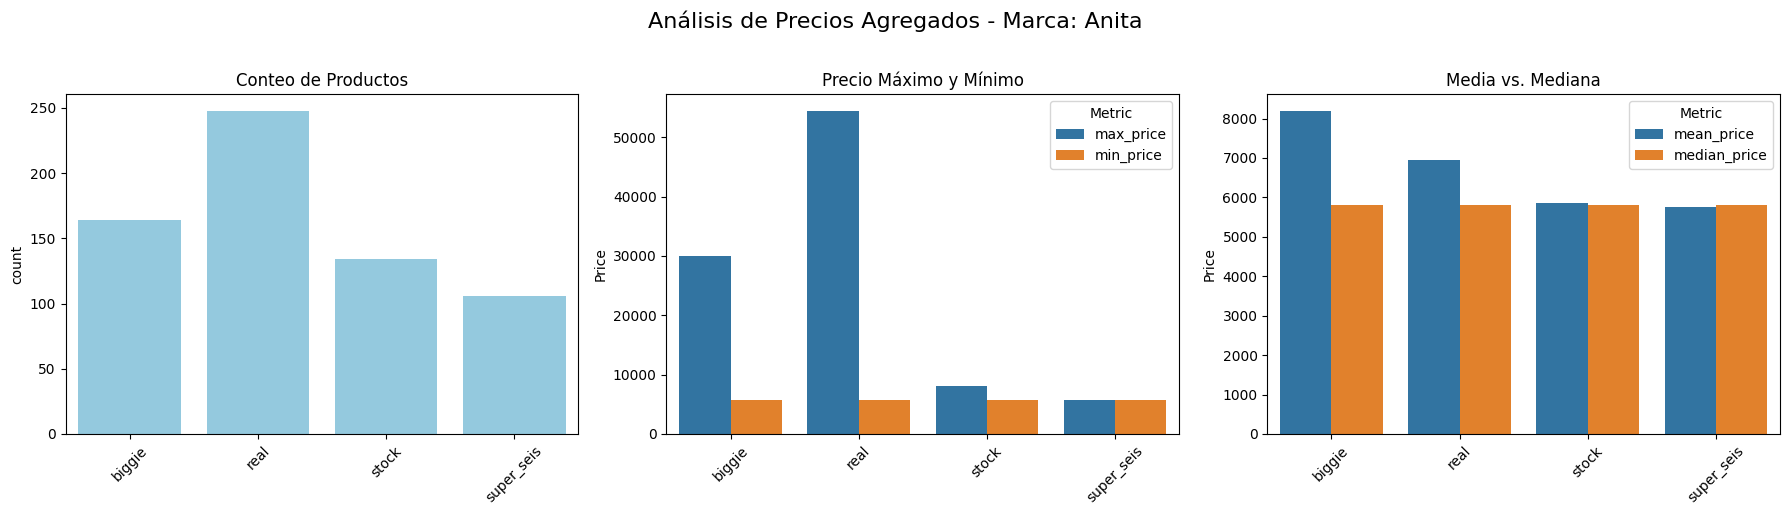

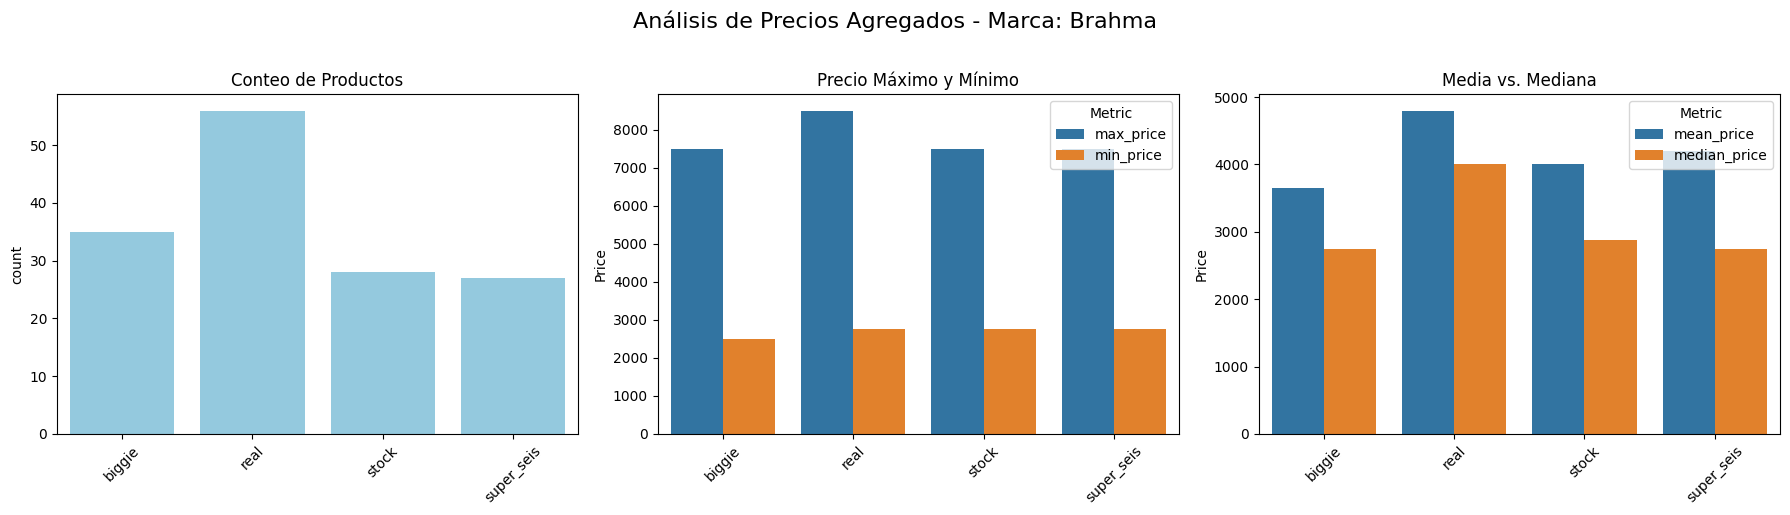

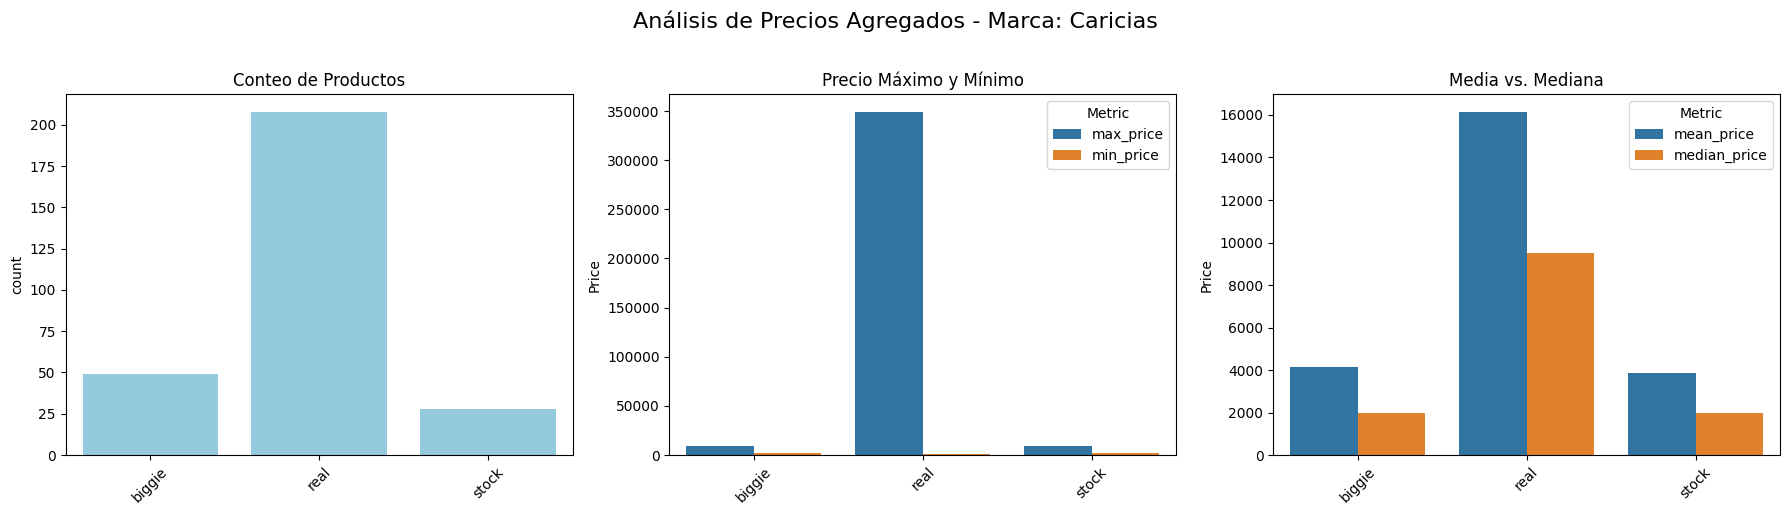

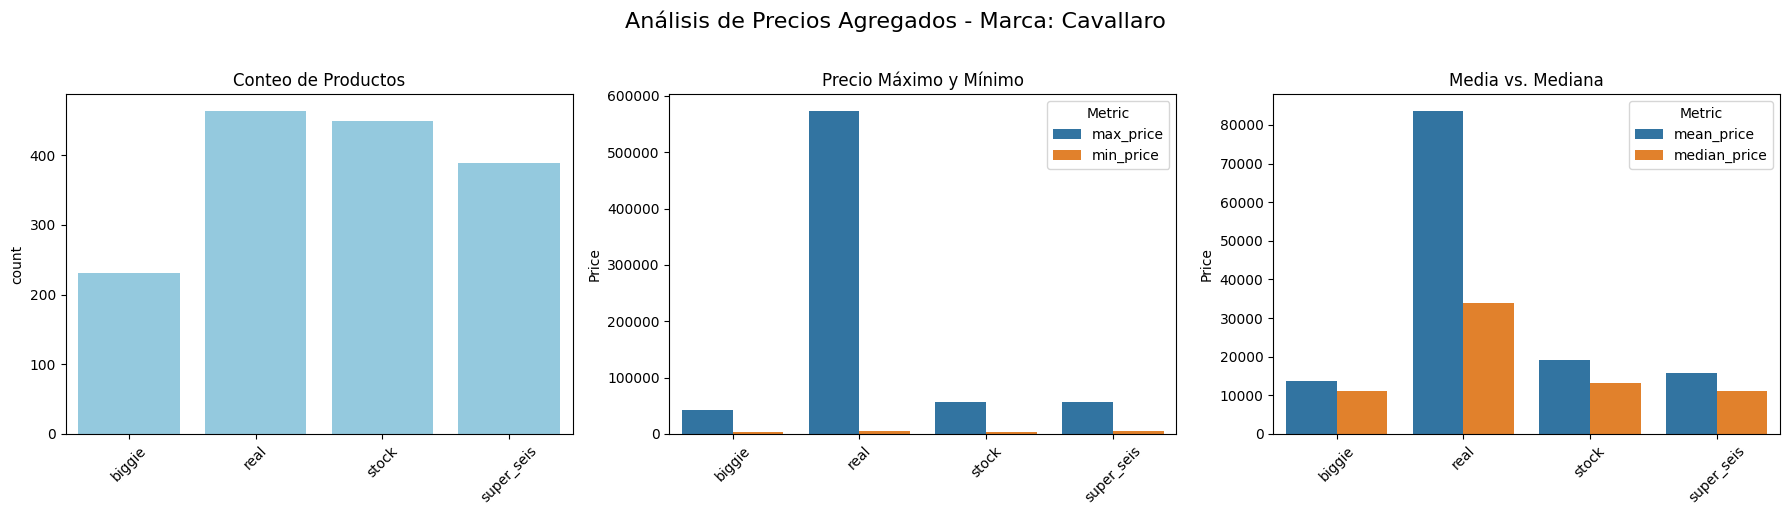

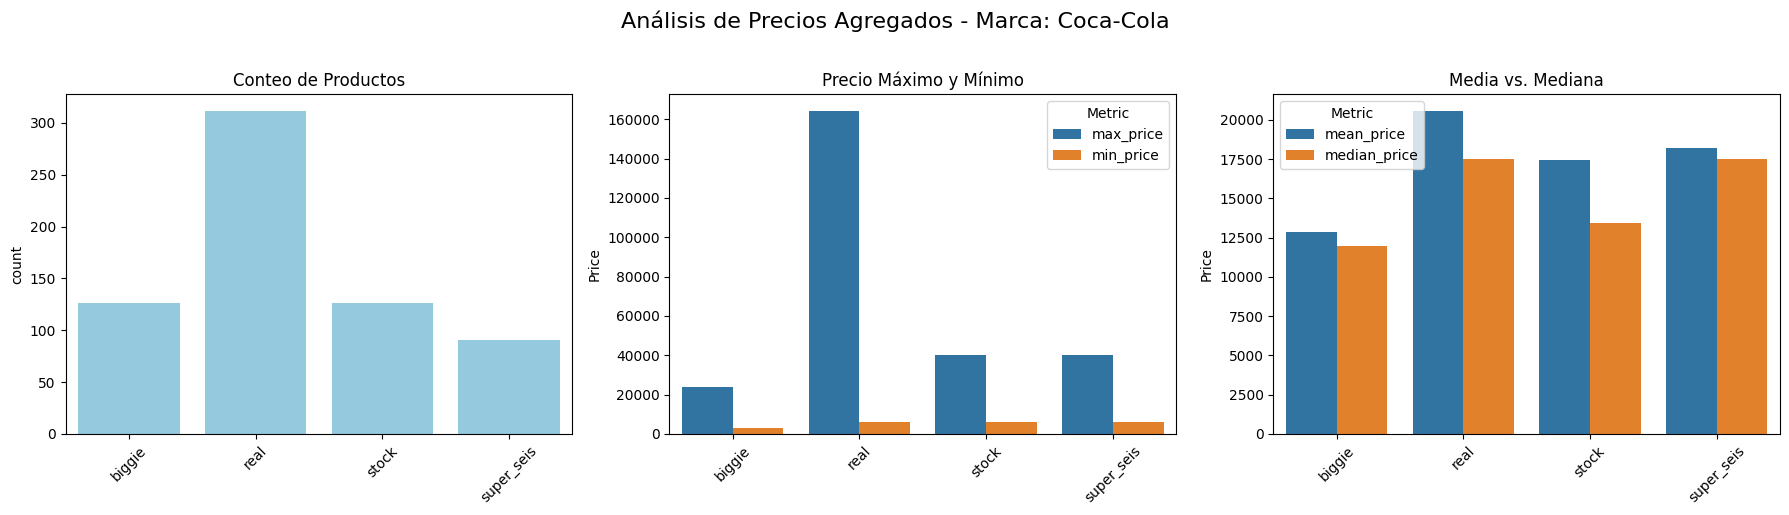

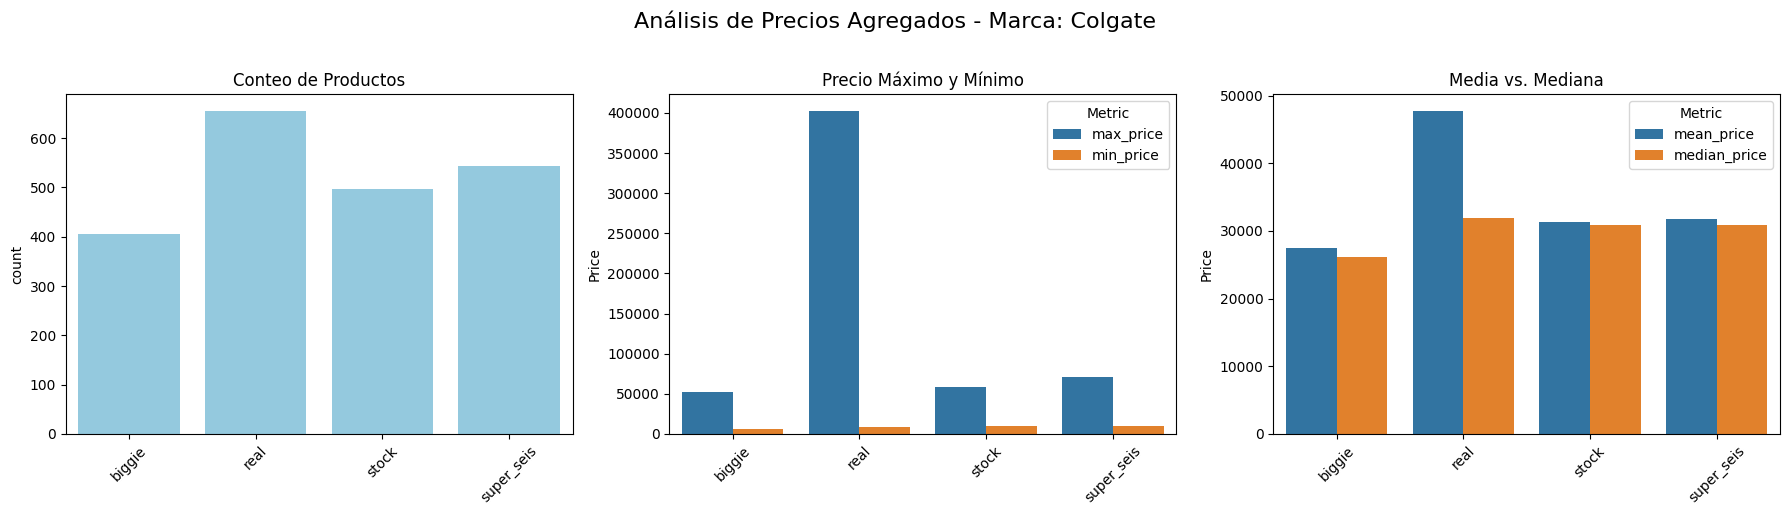

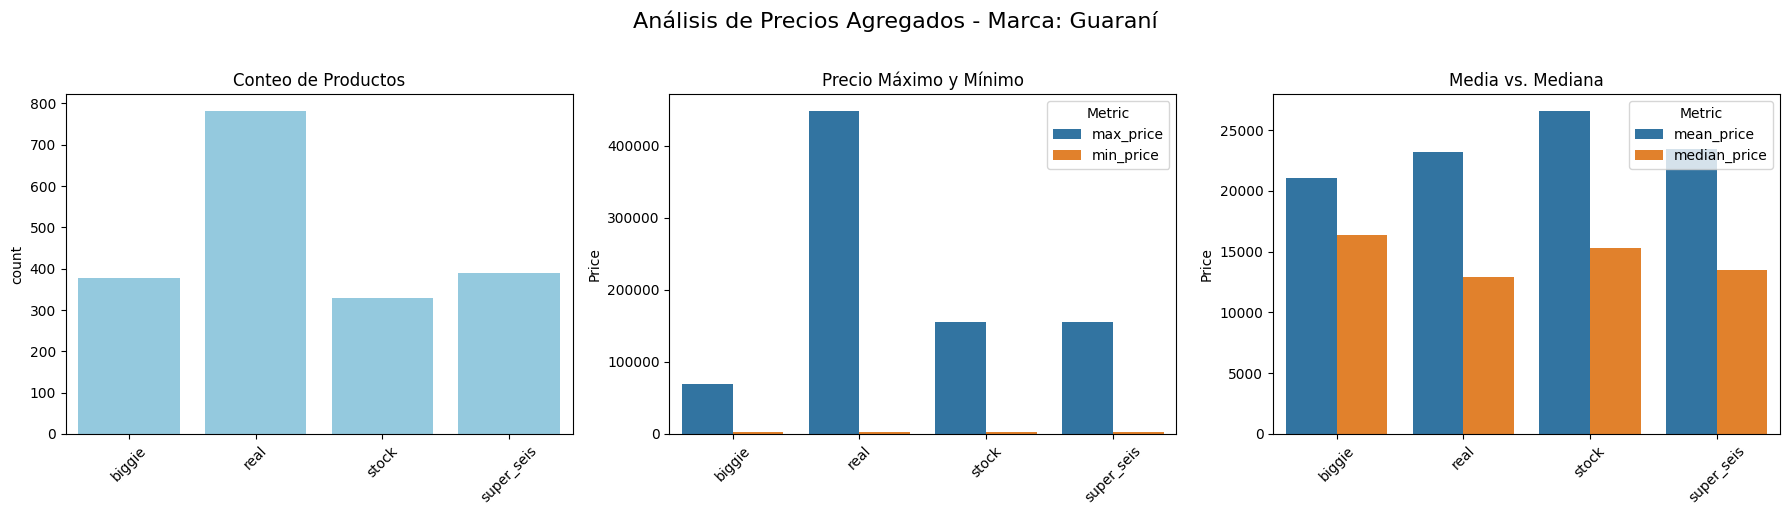

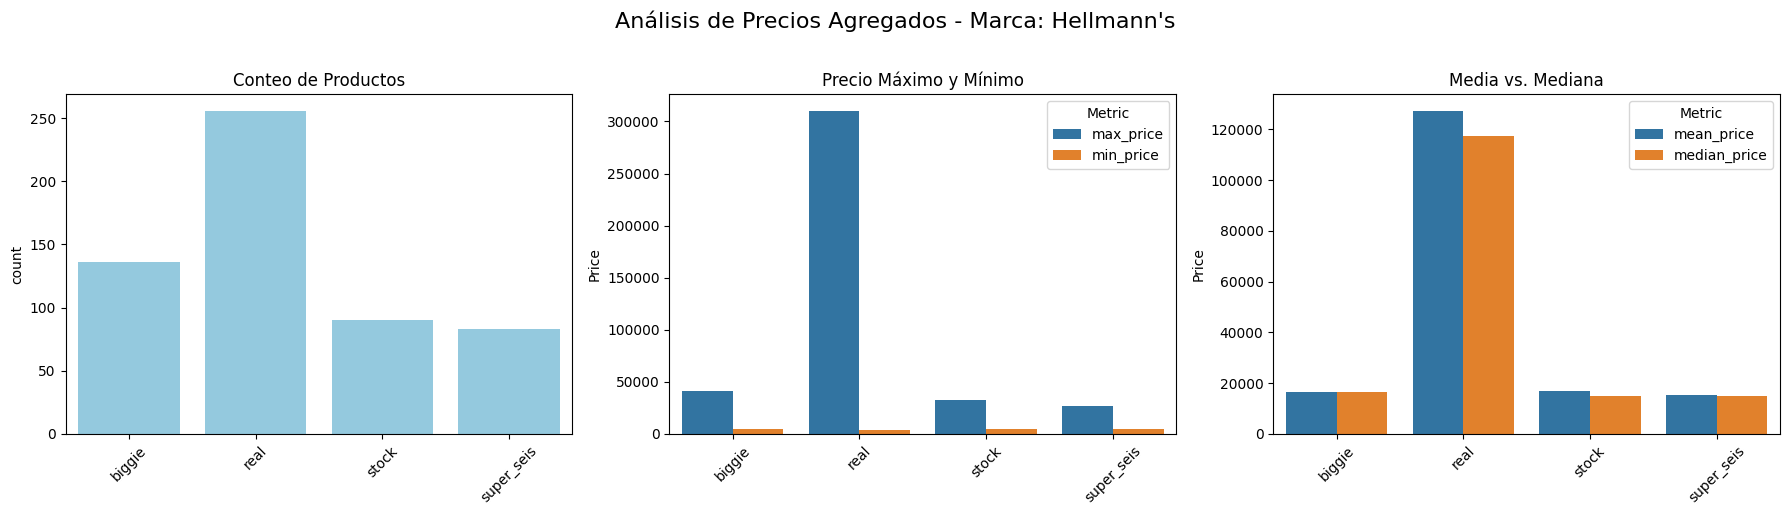

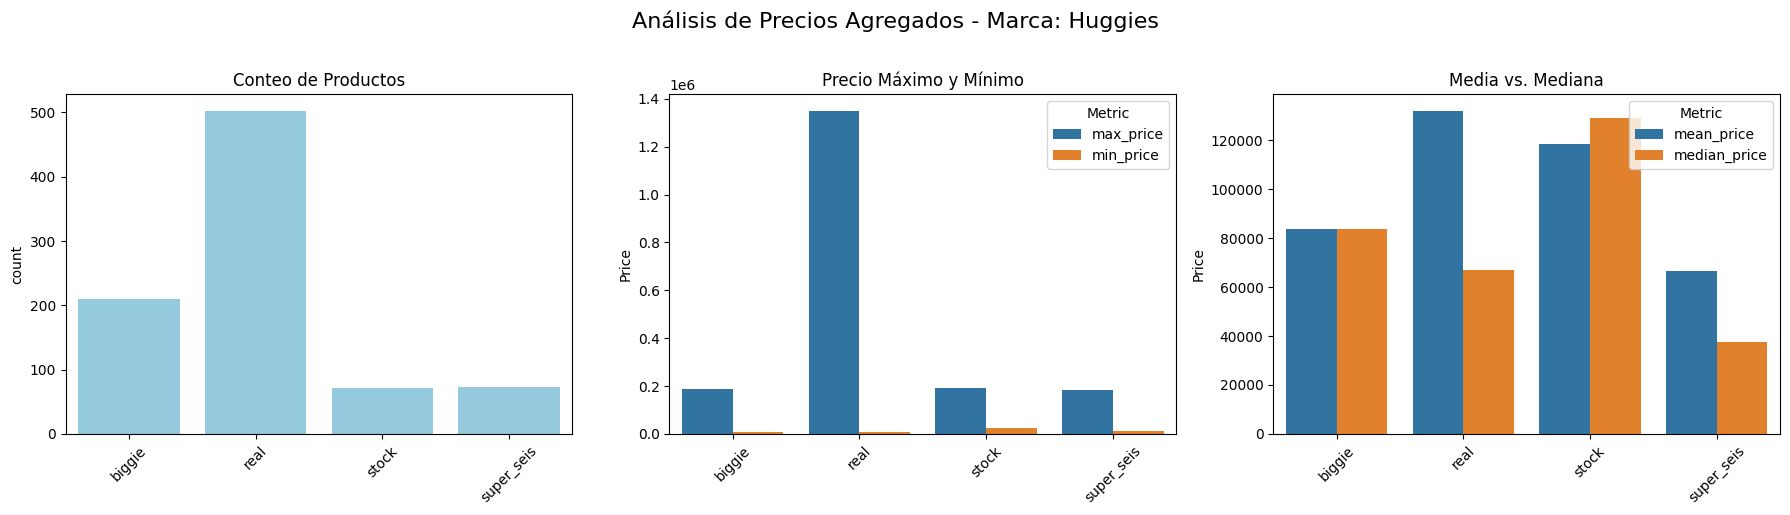

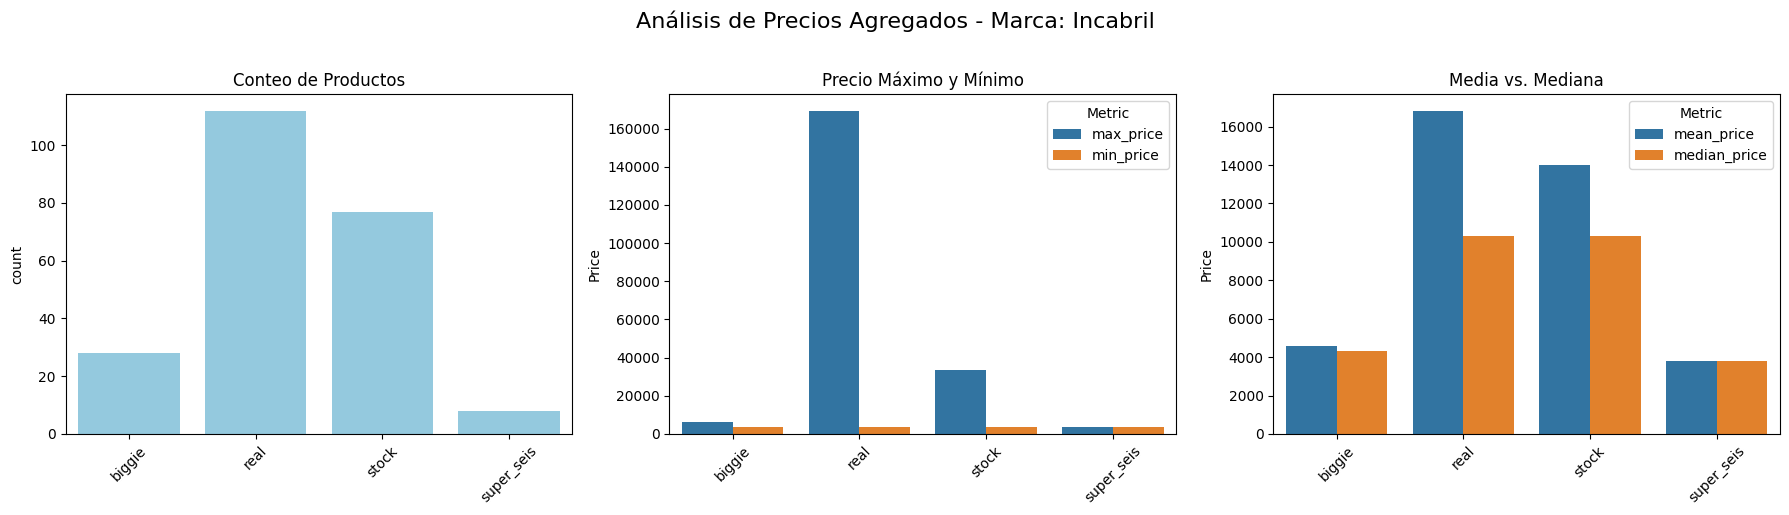

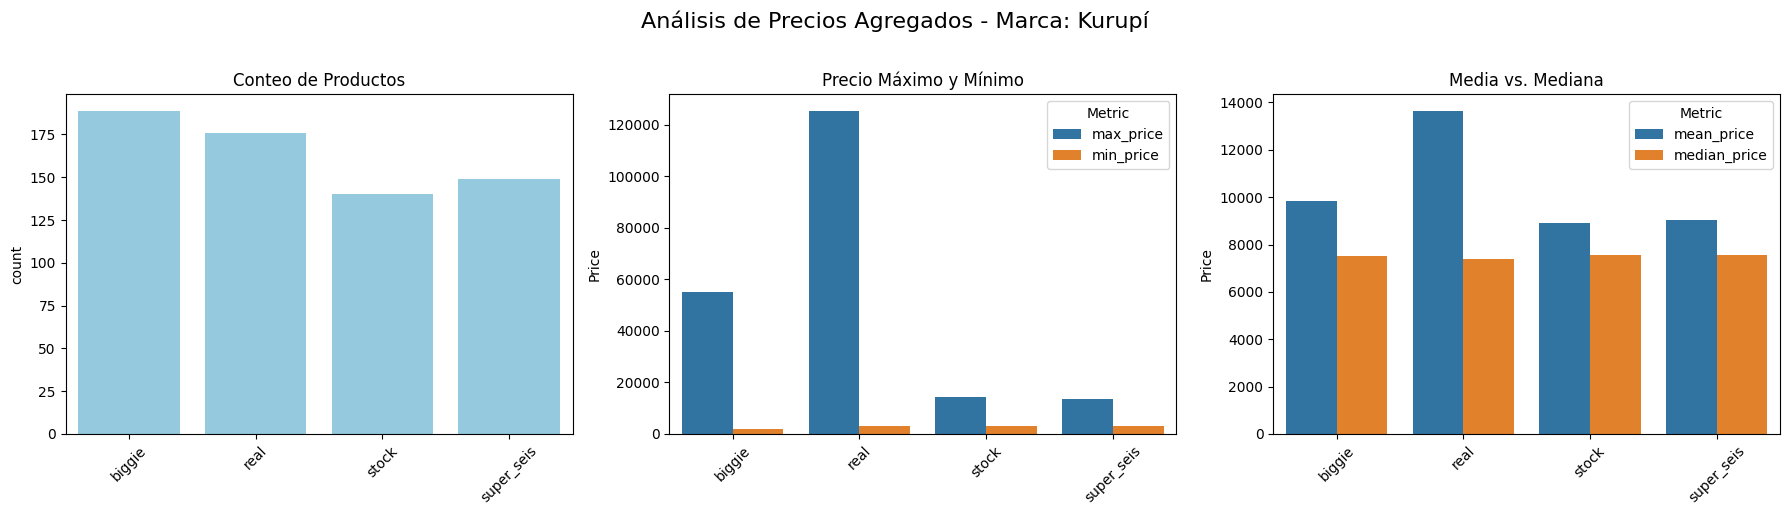

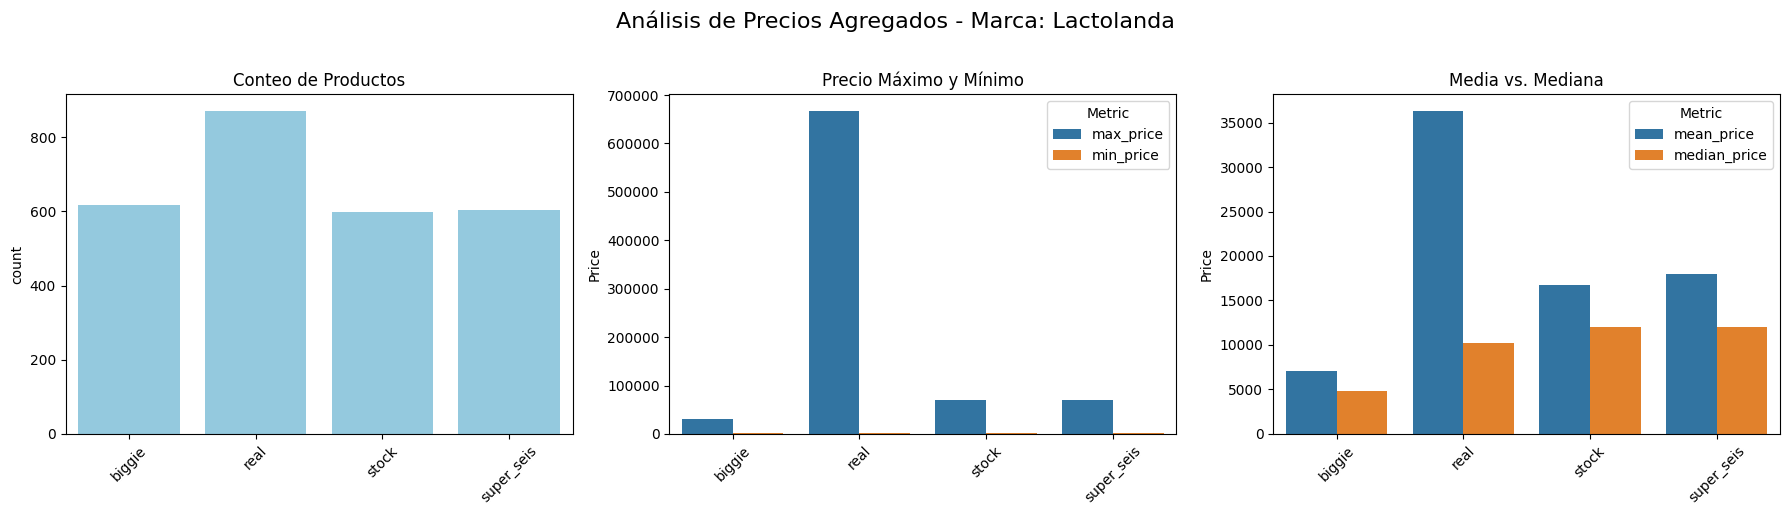

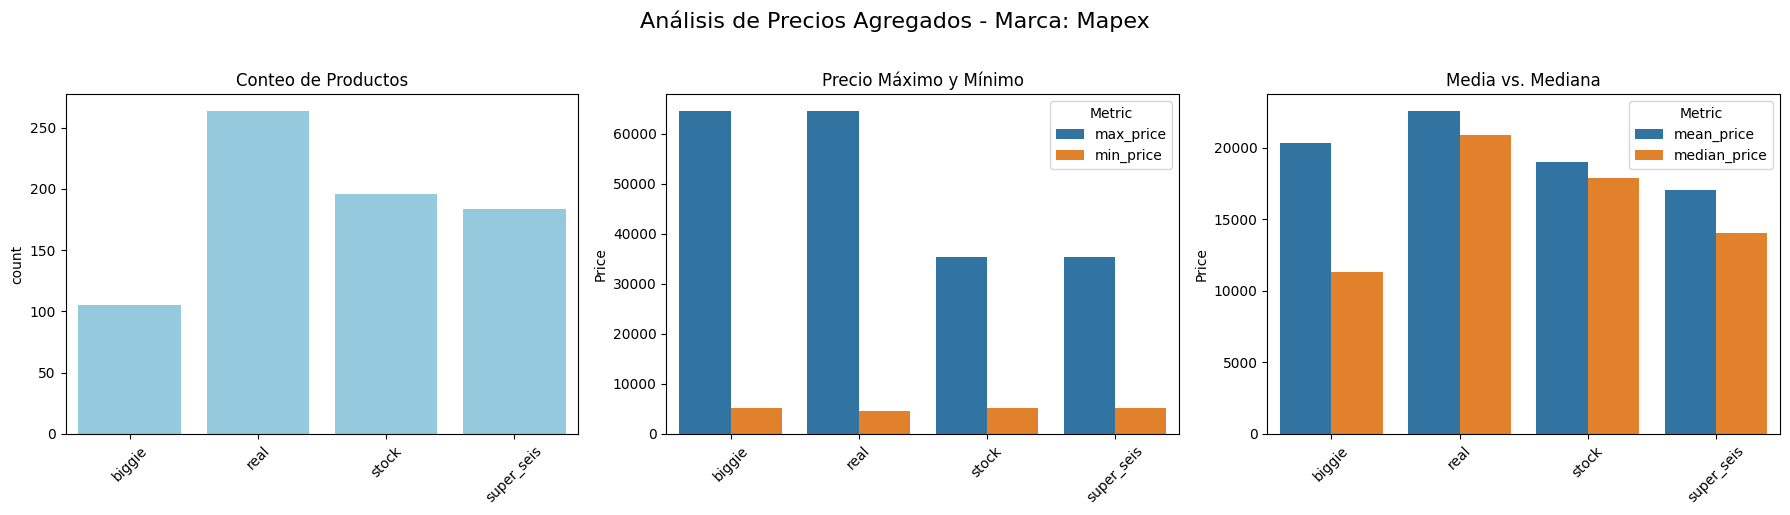

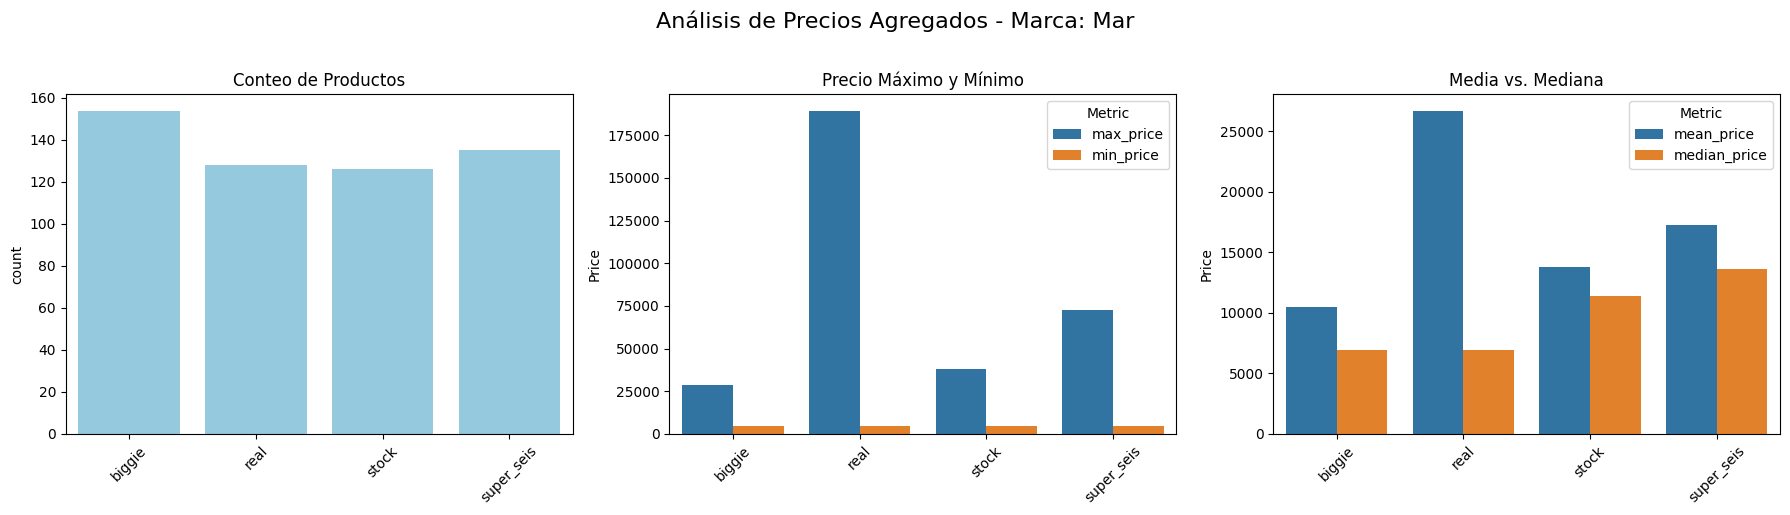

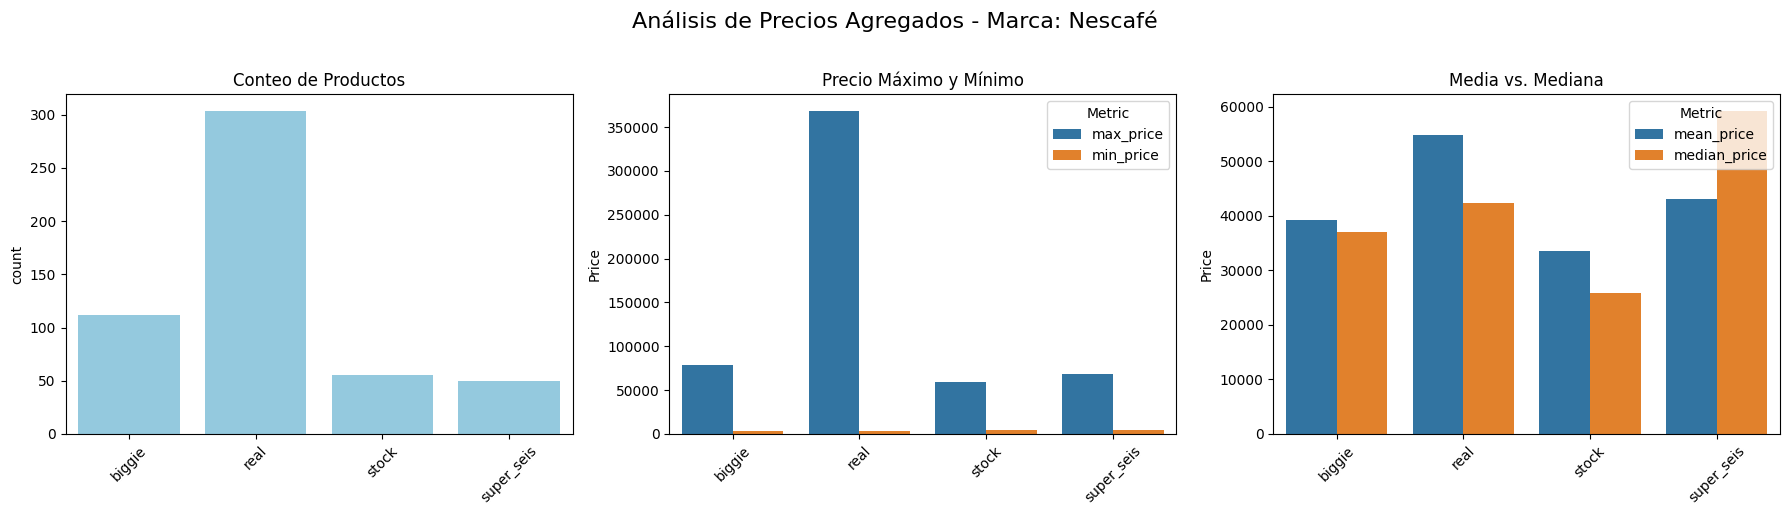

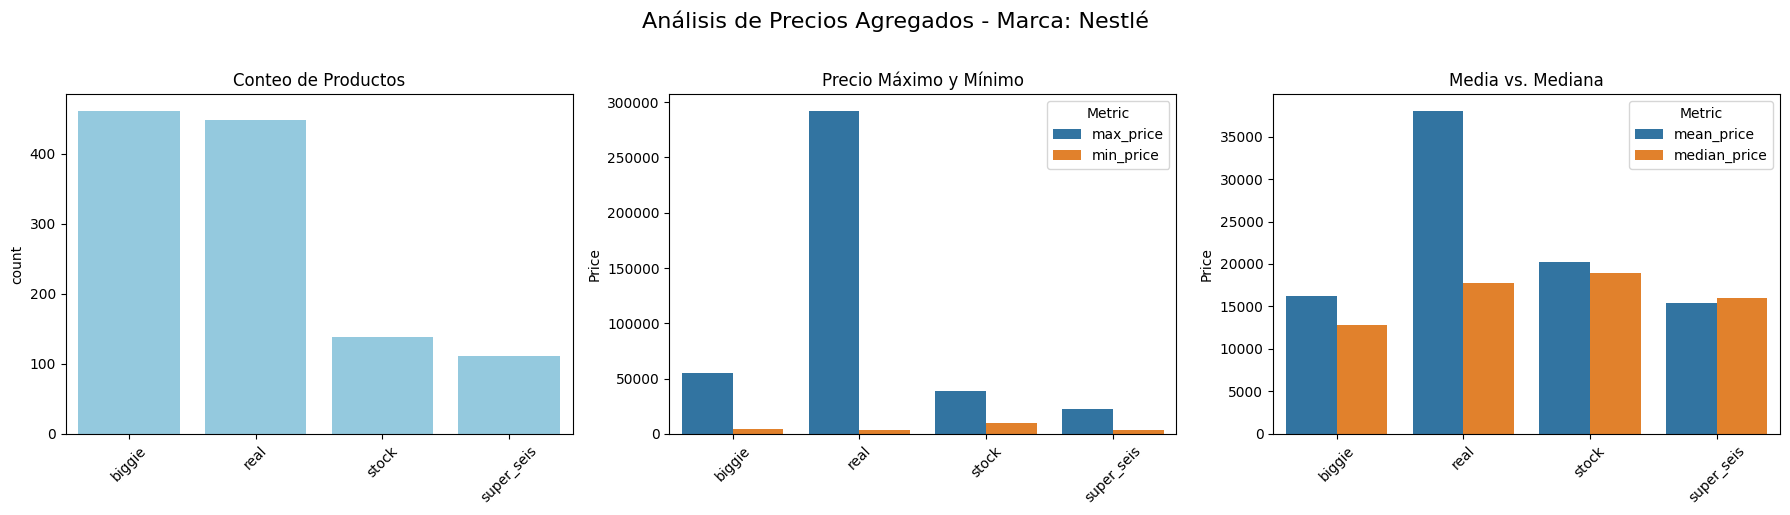

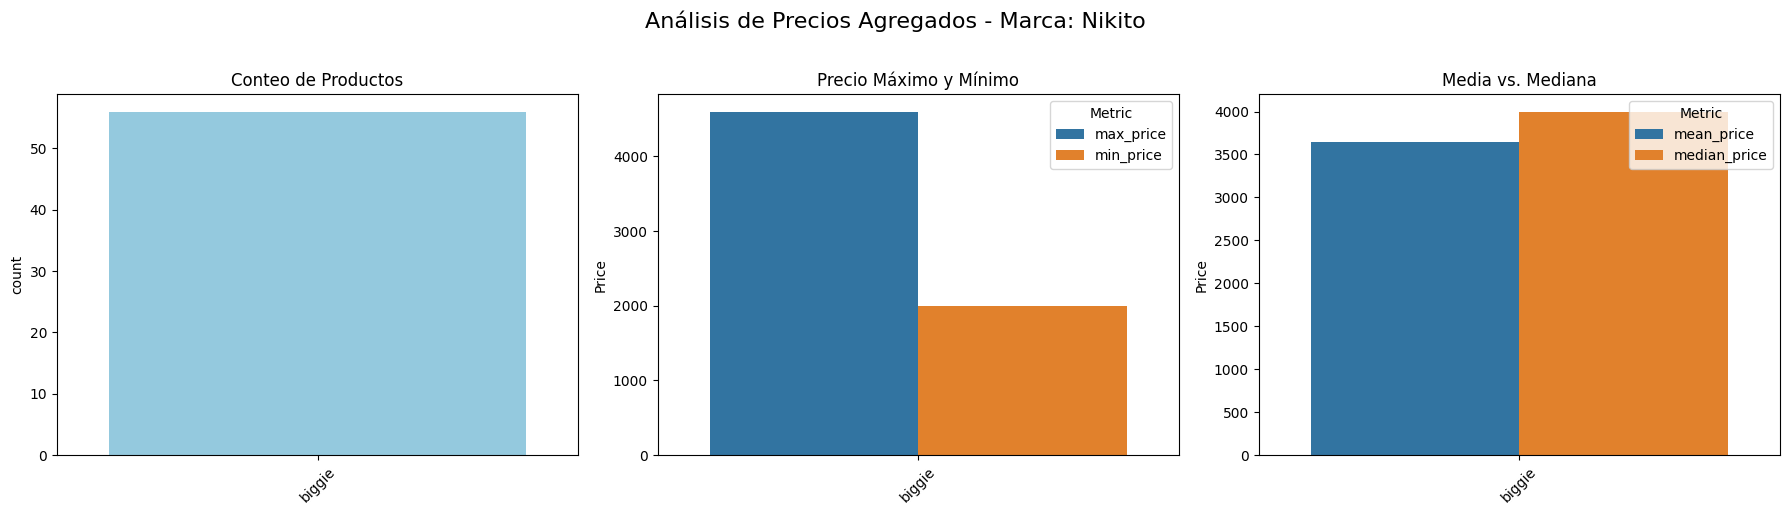

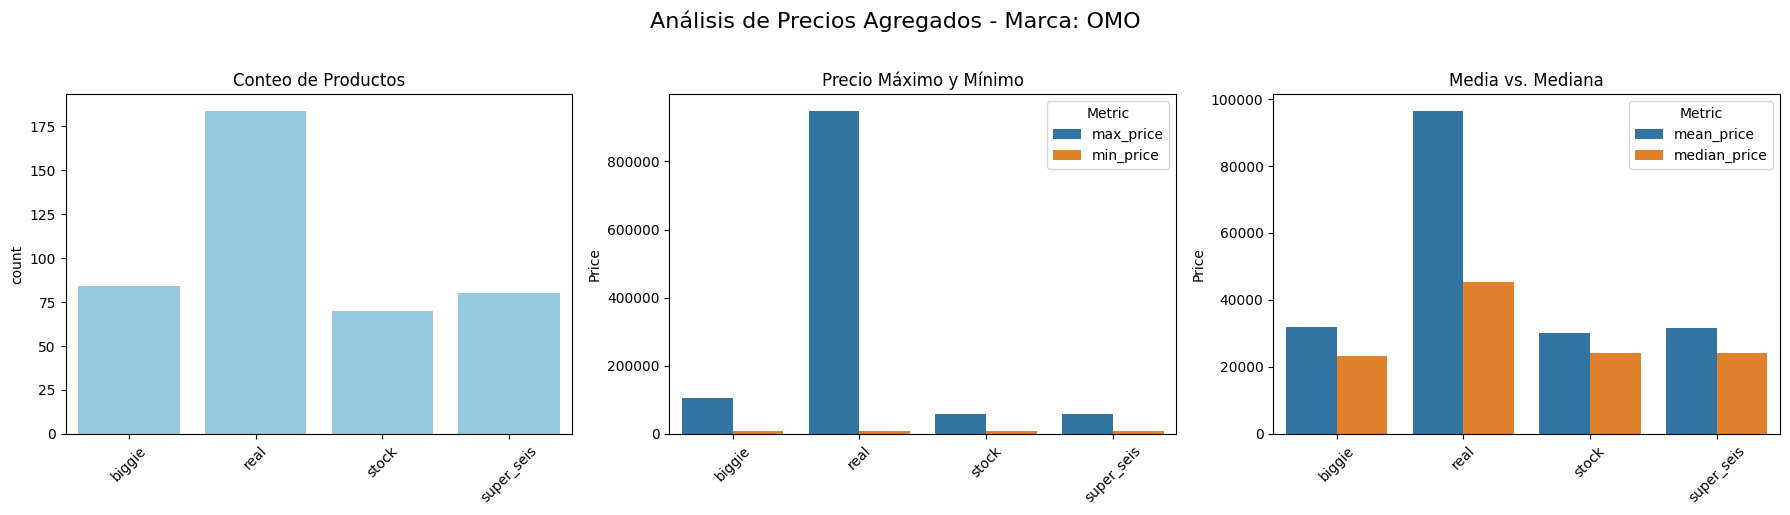

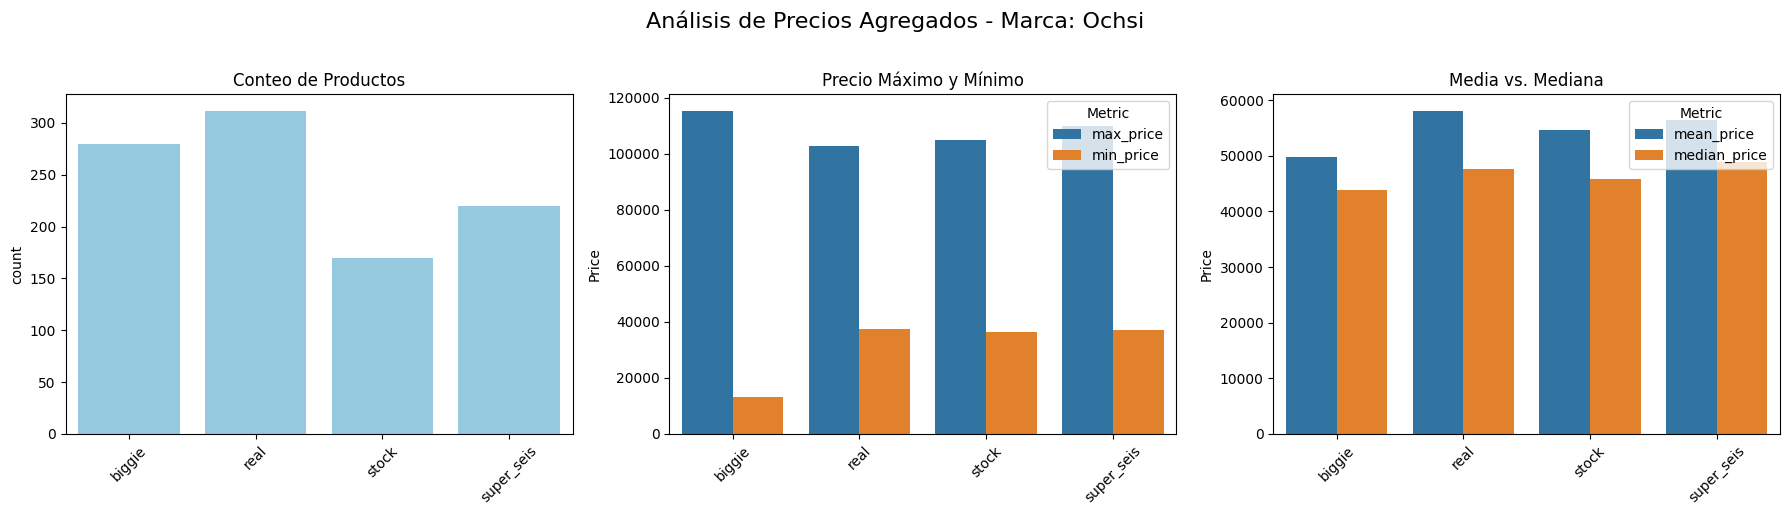

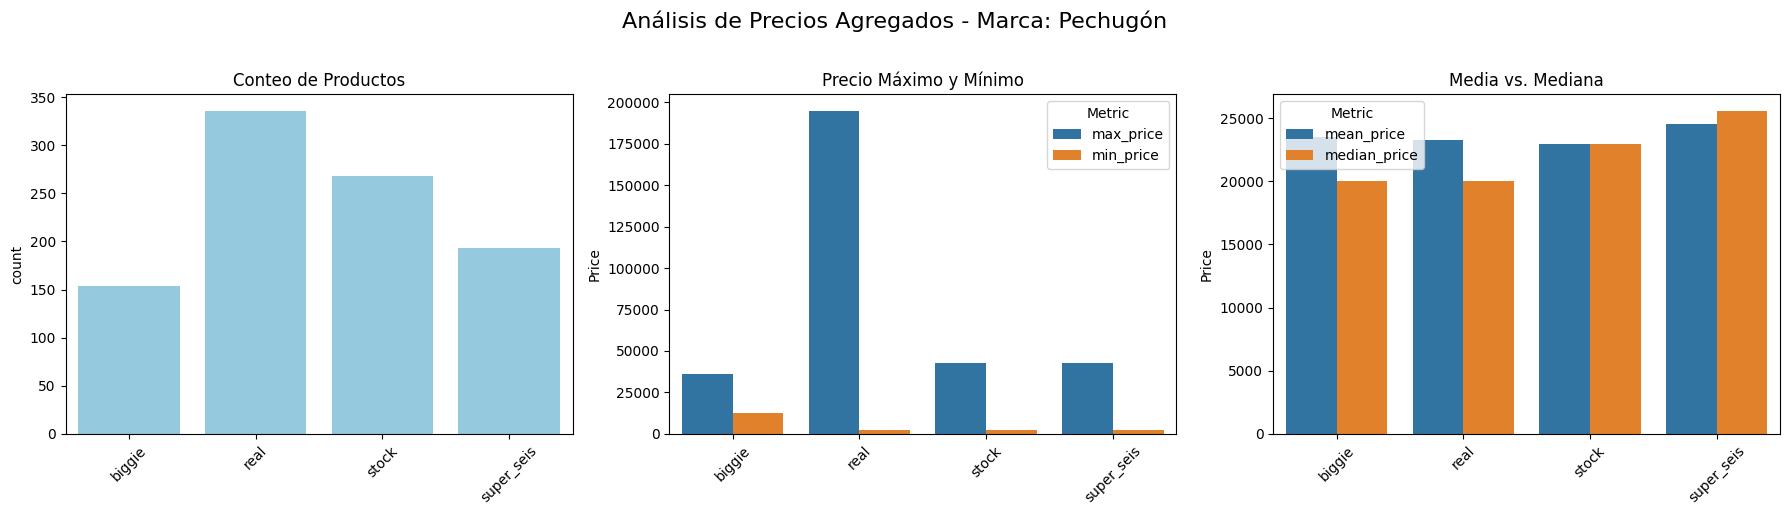

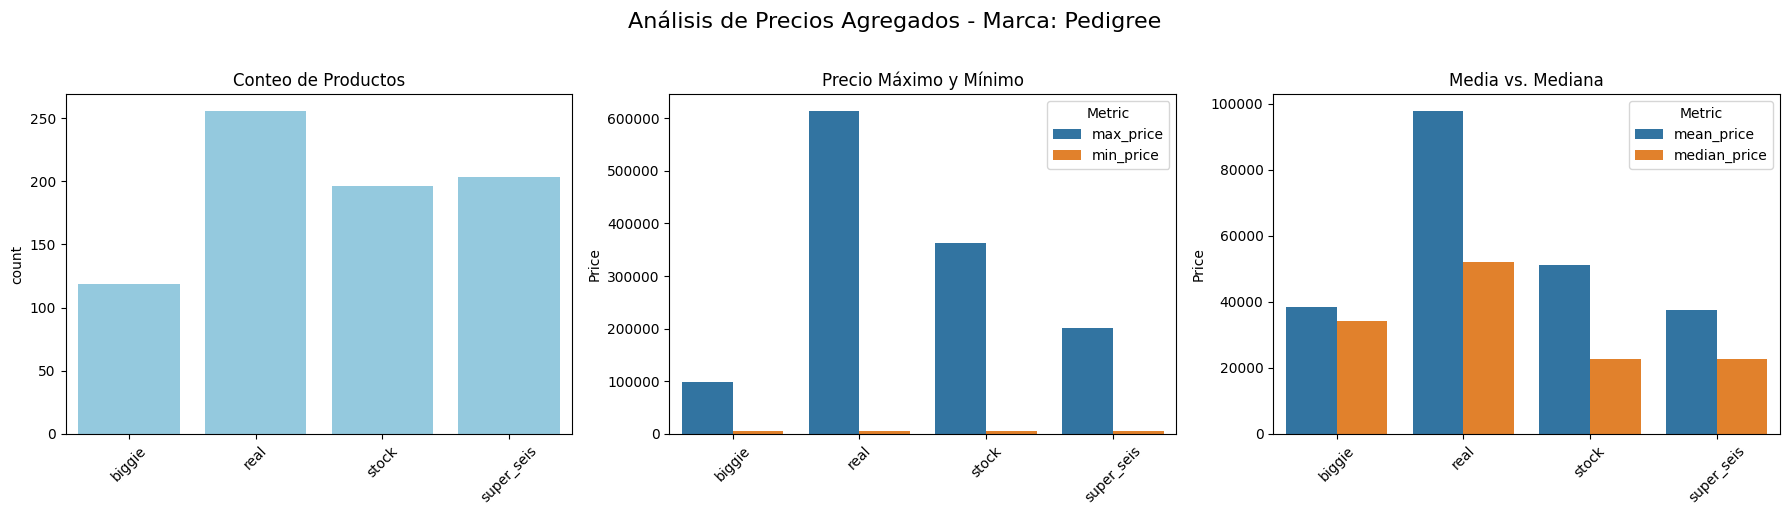

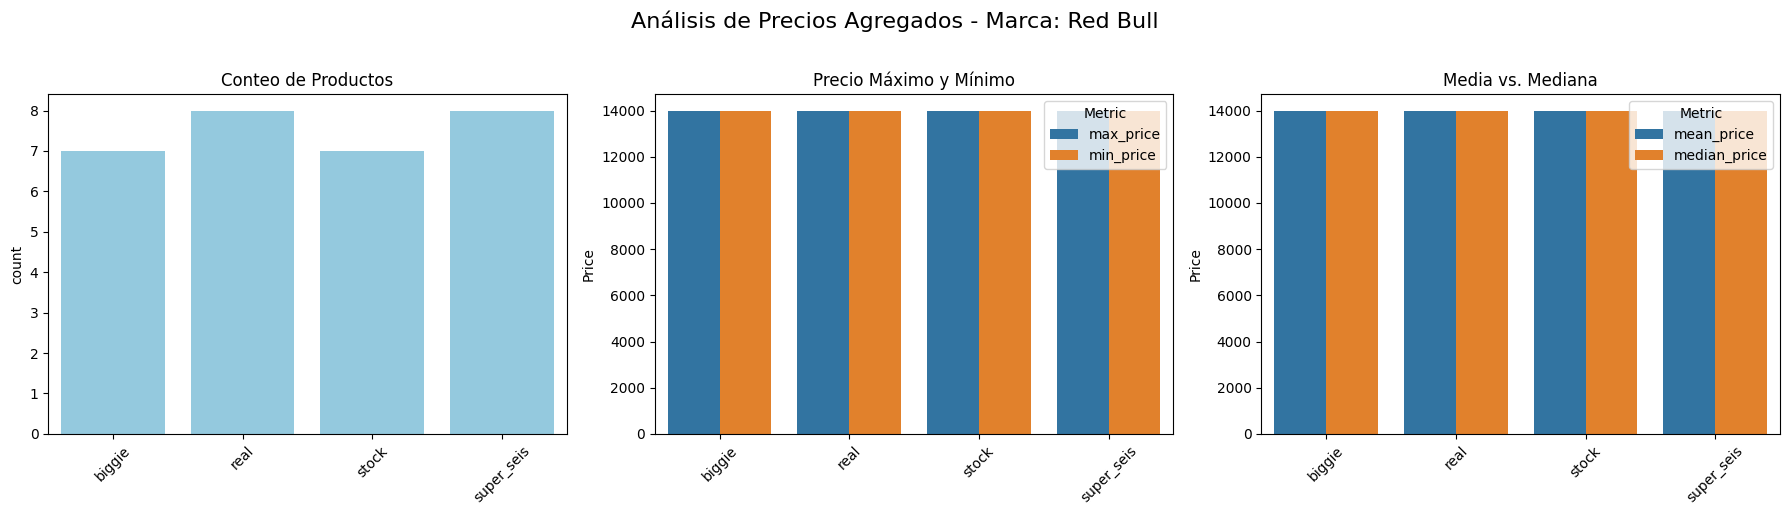

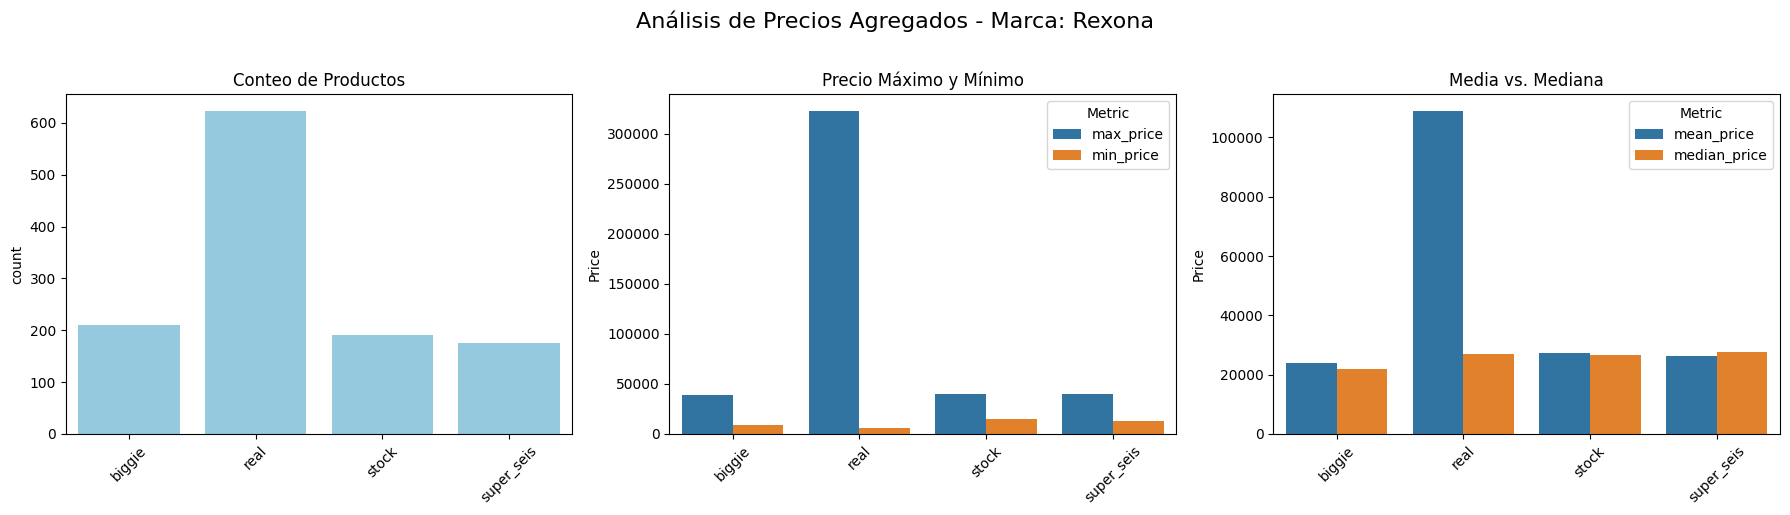

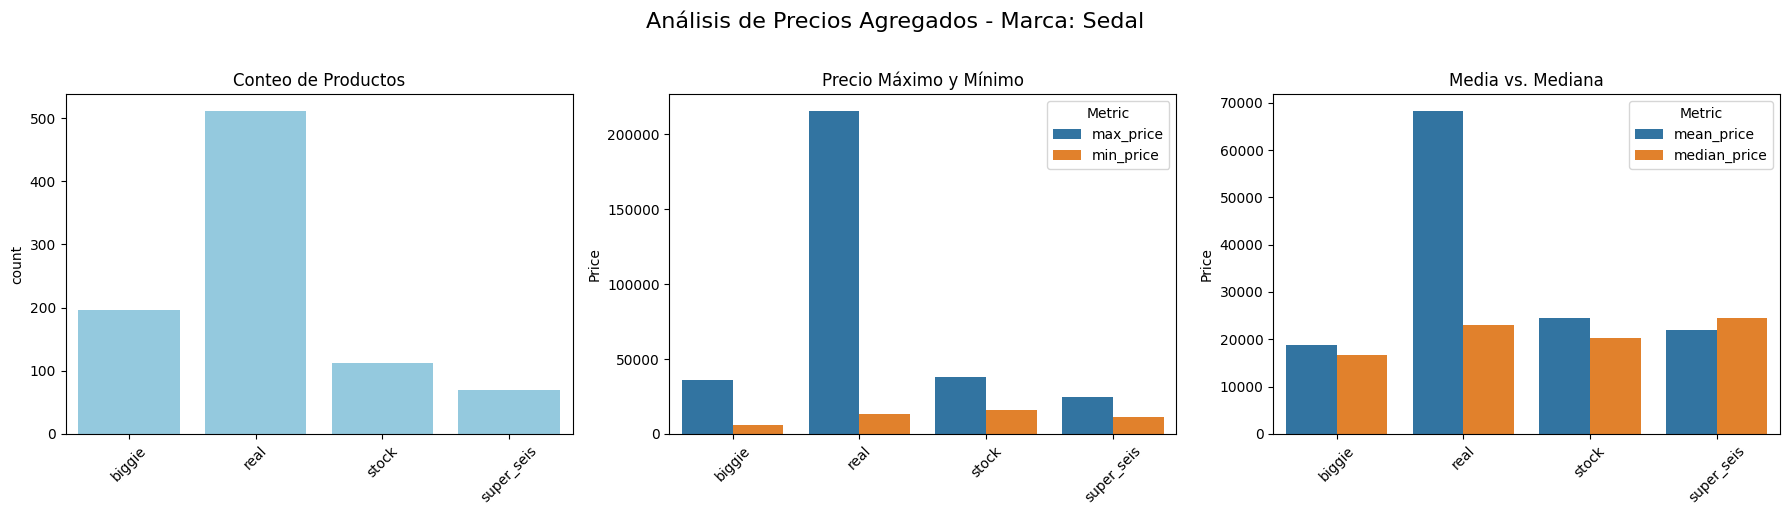

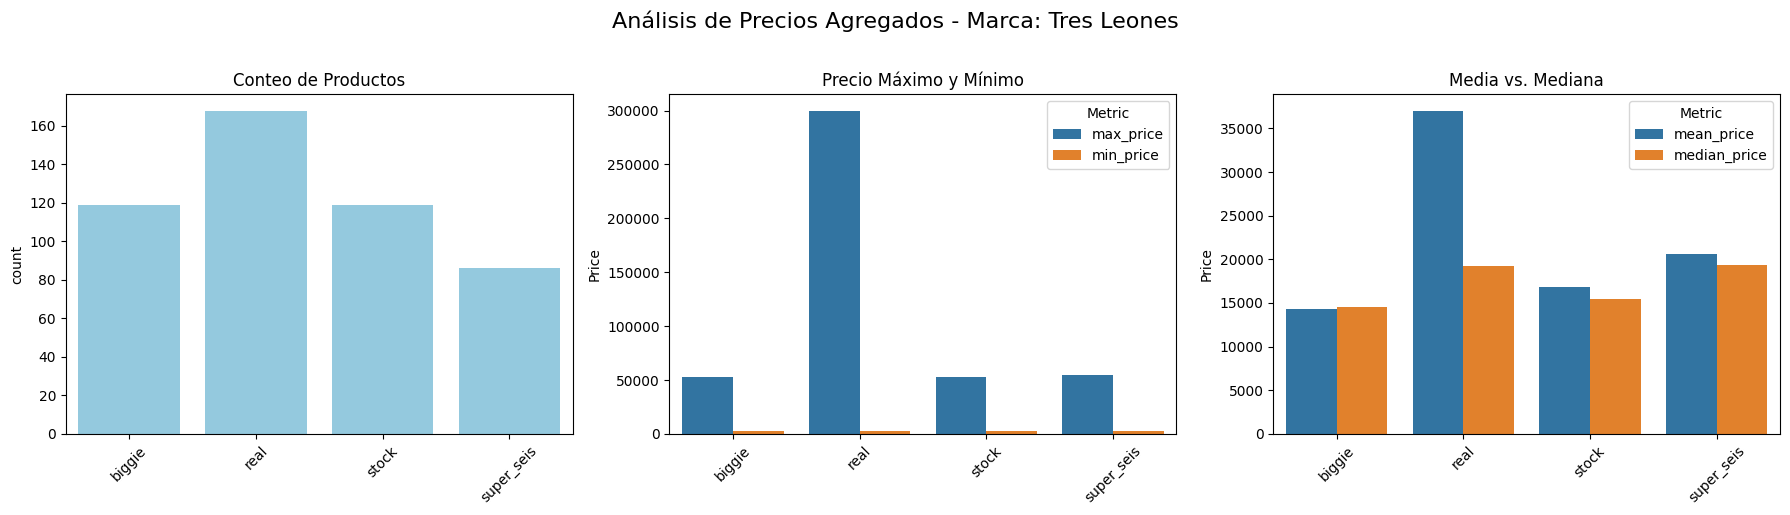

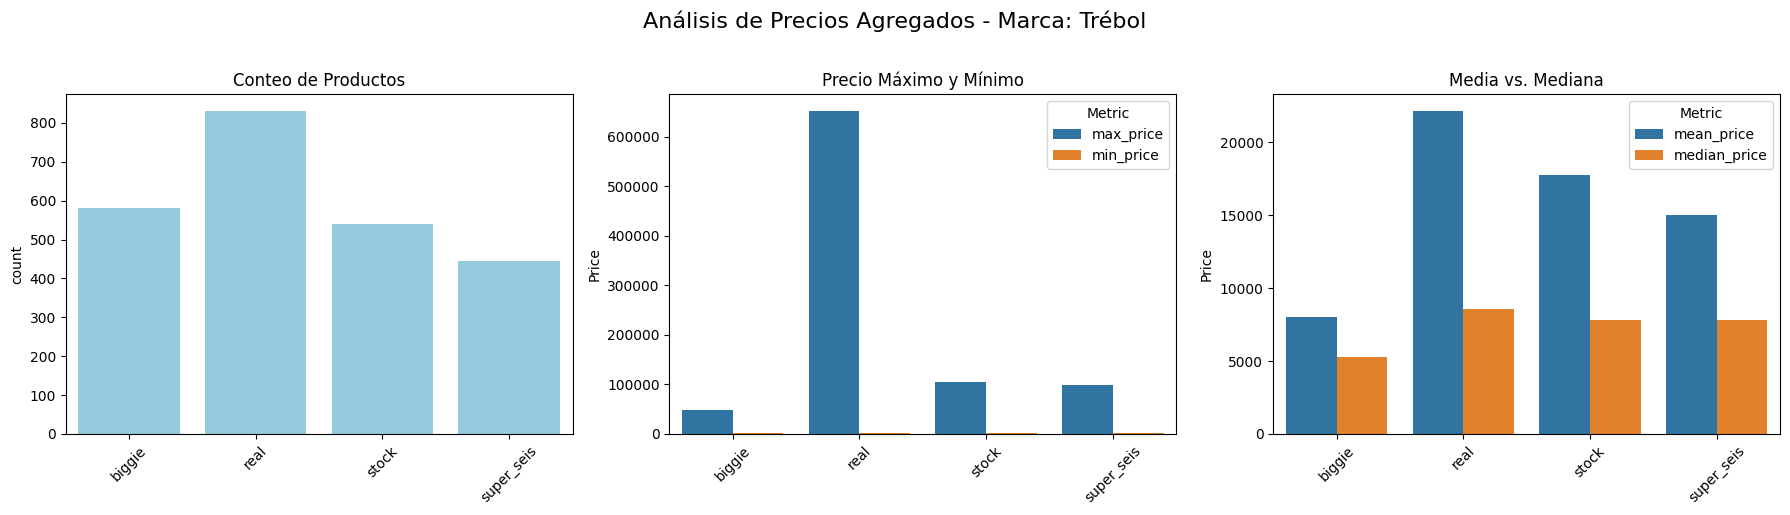

In [22]:
# Iteramos sobre cada marca TOM
for brand in tom_brands_list:
    brand_data = df_metrics[df_metrics['tom_brand'] == brand]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.suptitle(f'Análisis de Precios Agregados - Marca: {brand}', fontsize=16, y=1.02)

    # --- PLOT 1: Count (Cantidad de Productos) ---
    sns.barplot(
        data=brand_data, 
        x='supermarket', 
        y='count', 
        ax=axes[0],
        color='skyblue'
    )
    axes[0].set_title('Conteo de Productos')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=45)
    
    # --- PLOT 2: Max y Min Price (Range) ---
    range_data = brand_data[['supermarket', 'max_price', 'min_price']].melt(
        id_vars='supermarket', 
        var_name='Metric', 
        value_name='Price'
    )
    sns.barplot(
        data=range_data, 
        x='supermarket', 
        y='Price', 
        hue='Metric', 
        ax=axes[1]
    )
    axes[1].set_title('Precio Máximo y Mínimo')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=45)

    # --- PLOT 3: Mean y Median Price ---
    central_data = brand_data[['supermarket', 'mean_price', 'median_price']].melt(
        id_vars='supermarket', 
        var_name='Metric', 
        value_name='Price'
    )
    sns.barplot(
        data=central_data, 
        x='supermarket', 
        y='Price', 
        hue='Metric', 
        ax=axes[2]
    )
    axes[2].set_title('Media vs. Mediana')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()